# Regresión lineal: de los fundamentos a los LLM
**Inteligencia Artificial · UTB** — Edwin Puertas, PhD.

Notebook que acompaña la presentación `AI_Lecture08c_LinearRegression.pptx`. Contiene los **conceptos fundamentales**, los **8 supuestos del modelo lineal con su validación estadística** y **un ejemplo por cada uno de los 16 tópicos**, en el mismo orden de la presentación.

- Todos los datos son sintéticos o vienen incluidos en scikit-learn: **se ejecuta sin internet**.
- Cada sección es independiente (define sus propios datos y semillas).

| Bloque | Tópicos |
|---|---|
| 0 · Conceptos y supuestos | Variables, OLS, R², SE · S1–S8 |
| A · Fundamentos | 01–06 |
| B · Variantes modernas | 07–11 |
| C · Regresión lineal en la era de los LLM | 12–16 |

In [1]:
# Requisitos: numpy, scipy, scikit-learn, statsmodels, matplotlib
# !pip install numpy scipy scikit-learn statsmodels matplotlib
import numpy as np, matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import *
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
NAVY,CYAN,LIME,GREEN,INK,GRID="#2C4293","#2CB5E0","#A0CE3A","#098559","#1E2A5A","#D5DAEE"
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":8,"axes.edgecolor":"#8A93B8",
 "axes.labelcolor":INK,"xtick.color":INK,"ytick.color":INK,"axes.spines.top":False,"axes.spines.right":False,
 "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.5,"legend.frameon":False,"legend.fontsize":7})
def fig(): return plt.subplots(figsize=(7, 3.6), dpi=100)
def save(f, n=None): f.tight_layout(); plt.show()



---
# Bloque 0 · Conceptos fundamentales

## Variables del modelo

**Variable dependiente (Dependent variable, y)**
- Variable que se predice o se explica a partir de otras variables.
- También se llama respuesta, objetivo o target.
- Ejemplo: la nota del examen en un estudio sobre rendimiento académico.

**Variables independientes (Independent variables, x)**
- Variables que se usan para predecir o explicar la variable dependiente.
- También se llaman predictores, regresores, covariables o features.
- Ejemplo: tiempo de estudio, horas de sueño, nivel de ansiedad.

**Tipos de variables**
- Numéricas continuas (horas), discretas (n.º de cursos) o categóricas (programa).
- En regresión lineal, y es numérica continua; las x pueden ser de cualquier tipo codificado.

**Fórmulas:** `y = f(x₁, x₂, x₃) + ε`

## Modelo lineal (Linear model)

**Definición**
- Modelo que asume una relación lineal entre las variables independientes y la variable dependiente.

**Forma simple: y = mx + b**
- y es la variable dependiente y x la variable independiente.
- m es la pendiente: cambio en y cuando x aumenta una unidad.
- b es el intercepto (y-intercept): valor de y cuando x = 0.

**Forma múltiple y notación del curso**
- y = β₀ + β₁x₁ + … + β_p x_p + ε, donde ε es el error aleatorio.
- β son los parámetros poblacionales; b₀, b₁, … son sus estimaciones (m ≡ b₁, b ≡ b₀).

**Fórmulas:** `y = mx + b` · `y = β₀ + β₁x₁ + … + β_p x_p + ε`

## Coeficientes y mínimos cuadrados

**Coeficientes de regresión (Regression coefficients)**
- Representan la relación entre cada variable independiente y la dependiente en el modelo.
- bⱼ: cambio esperado en y por +1 en xⱼ, manteniendo las demás x constantes.
- El signo indica la dirección; la magnitud depende de las unidades de xⱼ.

**Mínimos cuadrados ordinarios (Ordinary Least Squares, OLS)**
- Método que estima los parámetros minimizando la suma de los cuadrados de las diferencias entre valores observados y predichos.
- Residuo: eᵢ = yᵢ − ŷᵢ (barras verdes del gráfico).
- Solución cerrada: b = (XᵀX)⁻¹Xᵀy.

**Fórmulas:** `min Σ (yᵢ − ŷᵢ)²` · `b = (XᵀX)⁻¹ Xᵀ y`

## Coeficiente de determinación (R²)

**R cuadrado (R-squared, R²)**
- Mide qué tan bien se ajusta el modelo de regresión lineal a los datos.
- Indica la proporción de la varianza de la variable dependiente explicada por las variables independientes.
- Va de 0 (no explica nada) a 1 (explica todo) en los datos de entrenamiento.

**Descomposición**
- SST = Σ(yᵢ − ȳ)²: variación total; SSE = Σ(yᵢ − ŷᵢ)²: variación no explicada.
- SSR = SST − SSE: variación explicada por el modelo.

**Precauciones**
- R² siempre sube al agregar variables: usar R² ajustado o validación.
- Un R² alto no prueba causalidad ni que se cumplan los supuestos.

**Fórmulas:** `R² = 1 − SSE / SST` · `R²ₐⱼ = 1 − (1 − R²)(n − 1)/(n − p − 1)`

## Error estándar (Standard error)

**Error estándar de un coeficiente, SE(bⱼ)**
- Mide la variabilidad o incertidumbre de la estimación de cada coeficiente de regresión.
- Es la desviación estándar que tendría bⱼ si se repitiera el muestreo.
- Disminuye con más datos, más variabilidad en xⱼ y menos colinealidad.

**Error estándar de la regresión, s**
- Dispersión típica de los puntos alrededor de la recta, en unidades de y.

**Uso**
- Estadístico t = bⱼ / SE(bⱼ) para probar H₀: βⱼ = 0.
- Intervalo de confianza: bⱼ ± t₀.₉₇₅ · SE(bⱼ).

**Fórmulas:** `s = √( SSE / (n − p − 1) )` · `SE(bⱼ) = s · √[(XᵀX)⁻¹]ⱼⱼ`

### Ejemplo en Python — los conceptos en una salida de statsmodels

In [2]:
import numpy as np, statsmodels.api as sm

rng = np.random.default_rng(0)
n = 200                                   # estudio de rendimiento académico
estudio = rng.uniform(0, 10, n)           # independiente x₁ (h/semana)
sueno = rng.uniform(4, 9, n)              # independiente x₂ (h/noche)
ruido = rng.normal(0, 0.4, n)
nota = 1.5 + 0.6 * estudio + 0.3 * sueno + ruido   # dependiente y

X = sm.add_constant(np.column_stack([estudio, sueno]))
res = sm.OLS(nota, X).fit()               # mínimos cuadrados ordinarios

etiquetas = ["intercepto", "estudio", "sueño"]
for nom, b, se, t in zip(etiquetas, res.params, res.bse, res.tvalues):
    print(f"{nom:10s} b = {b:6.3f}   SE = {se:.3f}   t = {t:6.1f}")
print(f"R² = {res.rsquared:.3f}   R² ajustado = {res.rsquared_adj:.3f}")
print(f"Error estándar de la regresión s = {np.sqrt(res.scale):.3f}")

intercepto b =  1.406   SE = 0.144   t =    9.7
estudio    b =  0.599   SE = 0.009   t =   63.9
sueño      b =  0.317   SE = 0.020   t =   16.2
R² = 0.956   R² ajustado = 0.955
Error estándar de la regresión s = 0.399


### Error estándar visto por bootstrap
La desviación de la pendiente en 2.000 remuestreos coincide con el SE que reporta statsmodels.

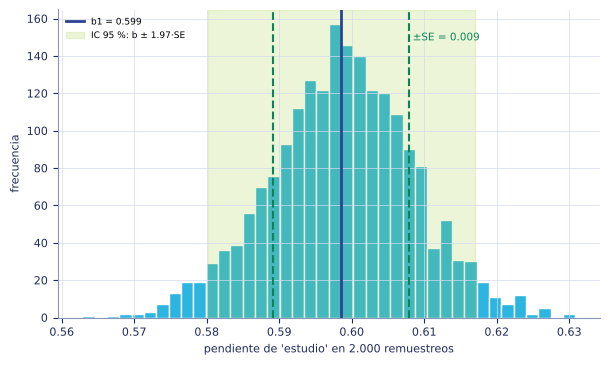

In [3]:
import statsmodels.api as sm
r = np.random.default_rng(1)
r0=np.random.default_rng(0); n=200; e=r0.uniform(0,10,n); s=r0.uniform(4,9,n); y=1.5+.6*e+.3*s+r0.normal(0,.4,n); X=sm.add_constant(np.c_[e,s]); res=sm.OLS(y,X).fit()
bs=[]
for _ in range(2000):
    i=r.integers(0,n,n); bs.append(np.linalg.lstsq(X[i],y[i],rcond=None)[0][1])
f,a=plt.subplots(figsize=(7,4),dpi=100); a.hist(bs,bins=40,color=CYAN,edgecolor="white")
b1,se=res.params[1],res.bse[1]; a.axvline(b1,c=NAVY,lw=2,label=f"b₁ = {b1:.3f}".replace("₁","1"))
for k in (-1,1): a.axvline(b1+k*se,c=GREEN,lw=1.5,ls="--")
a.axvspan(b1-1.97*se,b1+1.97*se,color=LIME,alpha=.2,label="IC 95 %: b ± 1.97·SE")
a.text(b1+se,a.get_ylim()[1]*.9,f" ±SE = {se:.3f}",color=GREEN,fontsize=7.5)
a.set_xlabel("pendiente de 'estudio' en 2.000 remuestreos"); a.set_ylabel("frecuencia"); a.legend(loc="upper left",fontsize=6.5); plt.show()


---
# Bloque 0 · Supuestos del modelo lineal y su validación

| Supuesto | Qué garantiza |
|---|---|
| 1 · Linealidad | Insesgadez |
| 2 · Exogeneidad | Insesgadez y consistencia |
| 3 · Independencia | SE válidos y eficiencia |
| 4 · Homocedasticidad | SE válidos y eficiencia (BLUE) |
| 5 · Normalidad | Inferencia exacta (t, F) con n pequeño |
| 6 · Sin multicolinealidad | Identificación y estabilidad de b |
| 7 · Sin influyentes | Robustez de las conclusiones |
| 8 · Muestra y medición | Validez externa y sin atenuación |

**Cómo leer una prueba:** H₀ afirma que el supuesto se cumple; p > 0.05 ⇒ no hay evidencia de violación; con n grande, mirar también el tamaño del efecto y los gráficos.

## S1 · Linealidad  —  `E[y | X] = Xβ`

**Qué significa**
- La media de y cambia de forma lineal con cada xⱼ (lineal en los parámetros).
- Incluye la forma funcional correcta: transformaciones e interacciones necesarias.

**Si se viola**
- Coeficientes sesgados y predicciones sistemáticamente erradas en ciertos rangos de x.

**Gráfico:** Residuos vs. ajustados y vs. cada xⱼ; gráficos de componente + residuo.

| Prueba | Hipótesis / criterio |
|---|---|
| RESET de Ramsey | H₀: no faltan potencias de ŷ (forma funcional correcta) |
| Harvey–Collier | H₀: la relación es lineal |
| Rainbow | H₀: el ajuste en el centro y en todo el rango es igual |

**Python:** `linear_reset(res, power=2) · linear_harvey_collier(res)`

**Remedios:** Transformar x o y (log, √, Box-Cox).; Agregar polinomios, splines o interacciones.; Usar un modelo no lineal.

## S2 · Exogeneidad (error de media cero)  —  `E[ε | X] = 0`

**Qué significa**
- El error no está correlacionado con ningún predictor.
- No hay variables omitidas relevantes, causalidad inversa ni error de medición en x.

**Si se viola**
- b sesgado e inconsistente: no mejora aunque crezca n.
- Es la violación más grave para interpretar efectos.

**Gráfico:** No se puede verificar con los residuos (OLS fuerza Xᵀe = 0): se razona con un DAG o la teoría del dominio.

| Prueba | Hipótesis / criterio |
|---|---|
| Durbin–Wu–Hausman | H₀: x es exógena (requiere una variable instrumental) |
| Sargan / Hansen | H₀: los instrumentos son válidos |
| RESET | detecta indirectamente variables omitidas no lineales |

**Python:** `IV2SLS(y, X, None, Z).fit() en linearmodels · linear_reset(res)`

**Remedios:** Incluir los confusores medidos.; Variables instrumentales (2SLS).; Efectos fijos con datos de panel o un experimento aleatorizado.

## S3 · Independencia de los errores  —  `Cov(εᵢ, εⱼ) = 0,  i ≠ j`

**Qué significa**
- El error de una observación no informa sobre el de otra.
- Suele fallar en series de tiempo, datos espaciales o agrupados (estudiantes por curso).

**Si se viola**
- b sigue siendo insesgado, pero los SE se subestiman.
- Los valores p y los intervalos son demasiado optimistas.

**Gráfico:** Residuos vs. orden o tiempo; función de autocorrelación (ACF) de los residuos.

| Prueba | Hipótesis / criterio |
|---|---|
| Durbin–Watson | ≈ 2 sin autocorrelación; < 1.5 positiva, > 2.5 negativa |
| Breusch–Godfrey | H₀: sin autocorrelación hasta el rezago p |
| Ljung–Box | H₀: autocorrelaciones conjuntas iguales a 0 |

**Python:** `durbin_watson(e) · acorr_breusch_godfrey(res, nlags=2)`

**Remedios:** Errores HAC de Newey–West.; Errores agrupados (cluster) por grupo.; GLS con errores AR(1) o modelos de series de tiempo.

## S4 · Homocedasticidad  —  `Var(ε | X) = σ²  (constante)`

**Qué significa**
- La dispersión de los errores es la misma para todo valor de x.
- Lo contrario (heterocedasticidad) aparece como un embudo.

**Si se viola**
- b insesgado pero ineficiente (no es BLUE).
- SE incorrectos ⇒ pruebas t y F inválidas.

**Gráfico:** Escala–ubicación: √|residuo estandarizado| vs. ŷ; residuos vs. cada xⱼ.

| Prueba | Hipótesis / criterio |
|---|---|
| Breusch–Pagan | H₀: varianza constante (lineal en X) |
| White | H₀: varianza constante (forma general, incluye cuadrados) |
| Goldfeld–Quandt | H₀: igual varianza en dos submuestras ordenadas |

**Python:** `het_breuschpagan(e, X) · het_white(e, X) · het_goldfeldquandt(y, X)`

**Remedios:** Errores estándar robustos HC3.; Mínimos cuadrados ponderados (WLS).; Transformar y (log) o modelar la varianza.

## S5 · Normalidad de los errores  —  `ε ~ N(0, σ²)`

**Qué significa**
- Los errores siguen una distribución normal.
- Solo se necesita para inferencia exacta con muestras pequeñas.

**Si se viola**
- b sigue siendo insesgado.
- Con n pequeño, intervalos y valores p no son exactos; con n grande el TLC lo mitiga.

**Gráfico:** Gráfico Q-Q de residuos e histograma con curva normal.

| Prueba | Hipótesis / criterio |
|---|---|
| Shapiro–Wilk | H₀: normalidad (potente con n < 5.000) |
| Jarque–Bera | H₀: asimetría 0 y curtosis 3 |
| Anderson–Darling / D'Agostino K² | H₀: normalidad (más peso en las colas) |

**Python:** `shapiro(e) · jarque_bera(e) · normal_ad(e)`

**Remedios:** Transformar y (Box-Cox, log).; Intervalos por bootstrap.; Regresión robusta si hay colas pesadas.

## S6 · Ausencia de multicolinealidad  —  `rango(X) = p + 1,  κ(X) moderado`

**Qué significa**
- Ningún predictor es combinación lineal (exacta o casi exacta) de otros.
- La colinealidad perfecta impide estimar; la alta la vuelve inestable.

**Si se viola**
- SE inflados, coeficientes inestables y con signos inesperados.
- La predicción puede seguir siendo buena.

**Gráfico:** Matriz de correlación y diagramas de dispersión entre predictores.

| Prueba | Hipótesis / criterio |
|---|---|
| VIF | VIFⱼ = 1/(1 − R²ⱼ); > 5 moderado, > 10 severo |
| Número de condición κ | κ > 30 indica colinealidad problemática |
| Proporciones de varianza (Belsley) | dos o más > 0.5 en el mismo índice alto |

**Python:** `variance_inflation_factor(X, j) · np.linalg.cond(X)`

**Remedios:** Eliminar o combinar predictores redundantes.; PCA o Ridge.; Centrar antes de crear interacciones o polinomios.

## S7 · Sin observaciones influyentes  —  `ningún punto domina a b`

**Qué significa**
- La estimación no depende de unos pocos datos.
- Se combinan apalancamiento (x extremo) y residuo grande.

**Si se viola**
- La recta se inclina hacia el punto influyente.
- Conclusiones que cambian al quitar una sola observación.

**Gráfico:** Residuos studentizados vs. apalancamiento con contornos de la distancia de Cook.

| Prueba | Hipótesis / criterio |
|---|---|
| Apalancamiento hᵢᵢ | alto si hᵢᵢ > 2(p + 1)/n |
| Residuo studentizado | atípico si |rᵢ| > 3 |
| Distancia de Cook, DFFITS, DFBETAS | Dᵢ > 4/n (revisar) o > 1 (grave); |DFBETAS| > 2/√n |

**Python:** `res.get_influence().summary_frame()`

**Remedios:** Verificar si es un error de captura.; Reportar el modelo con y sin el punto.; Regresión robusta (Huber, RANSAC).

## S8 · Muestra adecuada y x sin error  —  `n ≫ p,  Var(xⱼ) > 0,  x medido sin error`

**Qué significa**
- Suficientes observaciones por predictor (regla práctica: 10–20).
- x con variabilidad y medida con precisión; muestra representativa.

**Si se viola**
- Con error en x, b se atenúa hacia 0 (sesgo de atenuación).
- Con n pequeño, sobreajuste y baja potencia.

**Gráfico:** Curva de aprendizaje; comparar distribuciones de la muestra y la población.

| Prueba | Hipótesis / criterio |
|---|---|
| Confiabilidad de la medición | test–retest o alfa de Cronbach > 0.7 |
| Kolmogorov–Smirnov | H₀: muestra y población con la misma distribución |
| Análisis de potencia | n necesario para detectar el efecto esperado |

**Python:** `scipy.stats.ks_2samp(muestra, poblacion)`

**Remedios:** Recolectar más datos o reducir predictores.; Modelos de errores en variables (Deming).; Reponderar la muestra.

### Función `validar_supuestos()` — todas las pruebas en una llamada

In [4]:
import warnings, numpy as np, statsmodels.api as sm
import statsmodels.stats.diagnostic as dg
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from scipy.stats import shapiro
warnings.filterwarnings("ignore", category=FutureWarning)

def validar_supuestos(res, alfa=0.05):
    X, e, n = res.model.exog, res.resid, res.nobs
    p = {"Linealidad (RESET)": dg.linear_reset(res, power=2).pvalue,
         "Homocedasticidad (BP)": dg.het_breuschpagan(e, X)[1],
         "Independencia (BG)": dg.acorr_breusch_godfrey(res, nlags=2)[1],
         "Normalidad (Shapiro-Wilk)": shapiro(e).pvalue,
         "Normalidad (Jarque-Bera)": jarque_bera(e)[1]}
    for k, v in p.items():
        print(f"{k:26s} p = {v:.3f}  {'OK' if v > alfa else 'RECHAZA H0'}")
    vmax = max(vif(X, j) for j in range(1, X.shape[1]))
    cook = res.get_influence().cooks_distance[0]
    print(f"{'Durbin-Watson (≈ 2)':26s} {durbin_watson(e):.2f}")
    print(f"{'VIF máximo (< 5-10)':26s} {vmax:.1f}")
    print(f"{'Obs. con Cook > 4/n':26s} {int(np.sum(cook > 4 / n))}")

rng = np.random.default_rng(3)
x1 = rng.uniform(1, 10, 300); x2 = rng.normal(0, 1, 300)
y = 2 + 1.5 * x1 + 0.8 * x2 + rng.normal(0, 0.3 * x1)   # varianza crece con x1
validar_supuestos(sm.OLS(y, sm.add_constant(np.c_[x1, x2])).fit())

Linealidad (RESET)         p = 0.201  OK
Homocedasticidad (BP)      p = 0.000  RECHAZA H0
Independencia (BG)         p = 0.520  OK
Normalidad (Shapiro-Wilk)  p = 0.000  RECHAZA H0
Normalidad (Jarque-Bera)   p = 0.001  RECHAZA H0
Durbin-Watson (≈ 2)        1.90
VIF máximo (< 5-10)        1.0
Obs. con Cook > 4/n        25


### Panel de diagnóstico gráfico
1 residuos vs. ajustados · 2 Q-Q · 3 escala–ubicación · 4 residuos vs. apalancamiento (rojo: Cook > 4/n)

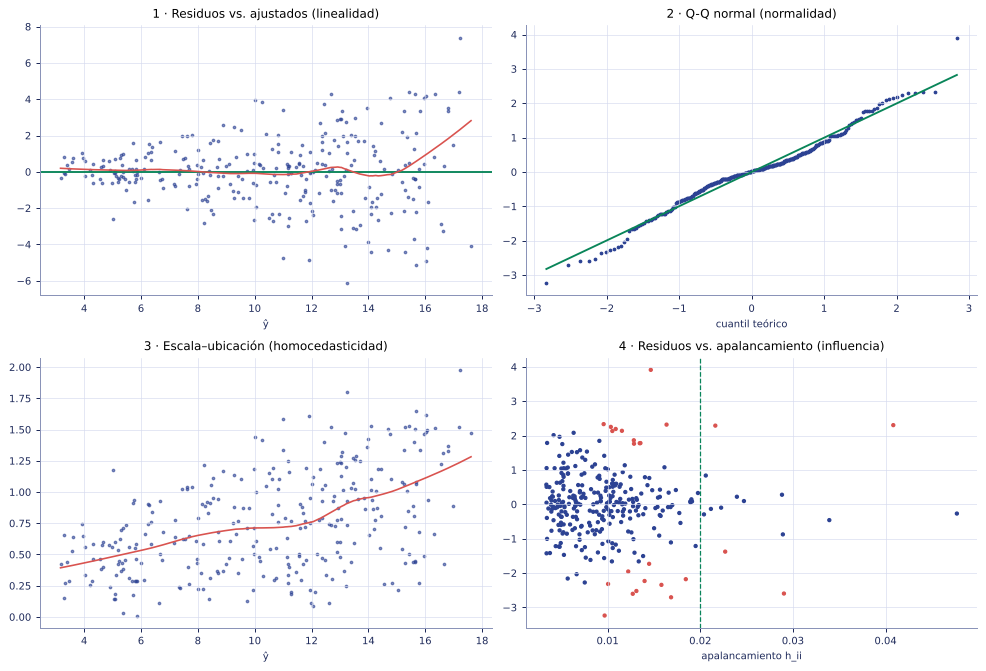

In [5]:
import statsmodels.api as sm
from scipy import stats
RED = '#D9534F'
r3=np.random.default_rng(3); x1=r3.uniform(1,10,300); x2=r3.normal(0,1,300); y=2+1.5*x1+.8*x2+r3.normal(0,.3*x1)
res=sm.OLS(y,sm.add_constant(np.c_[x1,x2])).fit(); inf=res.get_influence(); e=res.resid; yh=res.fittedvalues; rs=inf.resid_studentized_internal; h=inf.hat_matrix_diag; cd=inf.cooks_distance[0]
f,ax=plt.subplots(2,2,figsize=(11,7.5),dpi=90); o=np.argsort(yh)
a=ax[0,0]; a.scatter(yh,e,s=4,c=NAVY,alpha=.6); a.axhline(0,c=GREEN); lw_=sm.nonparametric.lowess(e,yh,frac=.3); a.plot(lw_[:,0],lw_[:,1],c=RED,lw=1.3); a.set_title("1 · Residuos vs. ajustados (linealidad)"); a.set_xlabel("ŷ")
a=ax[0,1]; (q,s_),(sl,ic,_)=stats.probplot(rs); a.scatter(q,s_,s=4,c=NAVY); a.plot(q,sl*q+ic,c=GREEN); a.set_title("2 · Q-Q normal (normalidad)"); a.set_xlabel("cuantil teórico")
a=ax[1,0]; sl_=np.sqrt(np.abs(rs)); a.scatter(yh,sl_,s=4,c=NAVY,alpha=.6); lw_=sm.nonparametric.lowess(sl_,yh,frac=.4); a.plot(lw_[:,0],lw_[:,1],c=RED,lw=1.3); a.set_title("3 · Escala–ubicación (homocedasticidad)"); a.set_xlabel("ŷ")
a=ax[1,1]; a.scatter(h,rs,s=6,c=np.where(cd>4/300,RED,NAVY)); a.axvline(2*3/300,c=GREEN,ls="--",lw=1); a.set_title("4 · Residuos vs. apalancamiento (influencia)"); a.set_xlabel("apalancamiento hᵢᵢ".replace("ᵢᵢ","_ii"))
f.tight_layout(); plt.show()

---
# Bloque A · Fundamentos
*Modelo, estimación, optimización, diagnóstico y evaluación*

## 01 · Modelo lineal simple y múltiple
*De la recta y = β₀ + β₁x a la forma matricial y = Xβ + ε*

- **Variable respuesta y:** cantidad continua que se quiere predecir o explicar (nota, precio, consumo).
- **Predictores x₁…x_p:** variables explicativas; pueden ser numéricas, binarias o transformadas.
- **Modelo simple:** y = β₀ + β₁x + ε; β₀ es el intercepto y β₁ la pendiente.
- **Modelo múltiple:** y = β₀ + β₁x₁ + … + β_p x_p + ε; cada βⱼ es el efecto de xⱼ con las demás fijas.
- **Forma matricial:** y = Xβ + ε, con X de tamaño n×(p+1) y una columna de unos para el intercepto.
- **“Lineal” significa lineal en β:** y = β₀ + β₁x + β₂x² sigue siendo un modelo lineal.
- **Error ε:** ruido no explicado; se asume E[ε | x] = 0.
- **Estimación:** b denota el valor estimado de β; la predicción ŷ = Xb estima E[y | x].

**Fórmulas clave:** `y = Xβ + ε` · `E[y | x] = β₀ + Σ βⱼ xⱼ`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Linealidad en los parámetros | Residuos vs. ajustados sin patrón; RESET de Ramsey (p > 0.05) | Transformar, polinomios o splines |
| Exogeneidad E[ε | X] = 0 | DAG con confusores; Durbin–Wu–Hausman si hay instrumento | Agregar confusores o usar VI |
| Rango completo de X | rank(X) = p + 1; número de condición κ < 30 | Quitar columnas redundantes |
| Errores i.i.d. con varianza constante | Breusch–Pagan, Durbin–Watson ≈ 2 | Errores robustos HC3 / HAC |
| Muestra representativa | Comparar distribuciones con la población (KS) | Reponderar o ampliar la muestra |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | Predecir la nota (0–10) de un estudiante. |
| **Datos** | 200 estudiantes; x₁ = horas de estudio, x₂ = horas de sueño. |
| **Modelo** | nota = b₀ + b₁·estudio + b₂·sueño (OLS). |
| **Resultado** | b = (1.41, 0.60, 0.32); ŷ(6 h, 7 h) = 7.22. |
| **Interpretación** | Cada hora extra de estudio suma 0.6 puntos con el sueño fijo. |

**Usos:** *Educación*: y: nota final · x: horas de estudio, asistencia, nota previa · *Economía*: y: demanda de un producto · x: precio, ingreso, precio del sustituto · *Ingeniería*: y: consumo energético de una planta · x: producción, temperatura · *Salud*: y: presión arterial · x: edad, IMC, consumo de sodio · *Marketing*: y: ventas semanales · x: inversión en radio, TV y redes · *Agro*: y: rendimiento por hectárea · x: lluvia, fertilizante, tipo de suelo

### Ejemplo en Python — Ajuste de un modelo múltiple

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(0)
n = 200                                   # horas de estudio y de sueño
X = np.column_stack([rng.uniform(0, 10, n), rng.uniform(4, 9, n)])
y = 1.5 + 0.6 * X[:, 0] + 0.3 * X[:, 1] + rng.normal(0, 0.4, n)   # nota (0-10)

modelo = LinearRegression().fit(X, y)
print("β0 (intercepto):", round(modelo.intercept_, 3))
print("β1, β2         :", np.round(modelo.coef_, 3))
print("ŷ(estudio=6, sueño=7):", round(modelo.predict([[6, 7]])[0], 2))

β0 (intercepto): 1.406
β1, β2         : [0.599 0.317]
ŷ(estudio=6, sueño=7): 7.22


**Qué observar**

- El intercepto absorbe lo que no explican x₁ y x₂.
- Los b quedan cerca de los reales (0.6 y 0.3).
- predict() aplica ŷ = β₀ + β₁x₁ + β₂x₂.

### Visualización

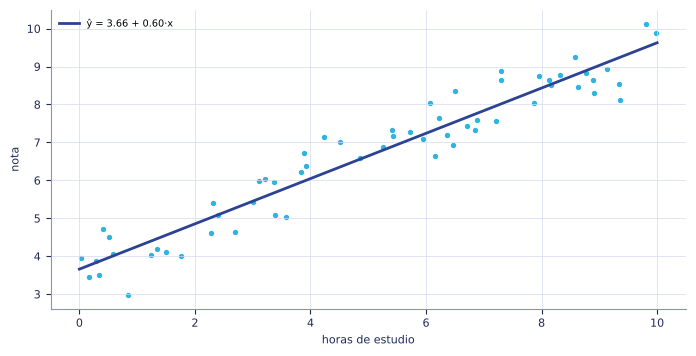

In [7]:
r=np.random.default_rng(0); x=r.uniform(0,10,60); y=1.5+0.6*x+2.1+r.normal(0,.5,60)
f,a=fig(); a.scatter(x,y,s=8,c=CYAN); b=np.polyfit(x,y,1); t=np.linspace(0,10,2)
a.plot(t,np.polyval(b,t),c=NAVY,lw=2,label=f"ŷ = {b[1]:.2f} + {b[0]:.2f}·x"); a.set_xlabel("horas de estudio"); a.set_ylabel("nota"); a.legend(); save(f,"f01.png")

## 02 · Mínimos cuadrados (OLS)
*Ecuación normal y lectura geométrica como proyección*

- **Criterio:** minimizar la suma de cuadrados de los residuos SSE(β) = ‖y − Xβ‖².
- **Ecuación normal:** XᵀX b = Xᵀy; si XᵀX es invertible, b = (XᵀX)⁻¹Xᵀy.
- **Residuos:** e = y − Xb; son ortogonales a cada columna de X (Xᵀe = 0).
- **Geometría:** ŷ es la proyección ortogonal de y sobre el espacio columna de X.
- **Matriz sombrero:** H = X(XᵀX)⁻¹Xᵀ, con ŷ = Hy; su diagonal mide el apalancamiento.
- **Gauss–Markov:** con errores homocedásticos e incorrelados, OLS es el mejor estimador lineal insesgado (BLUE).
- **Estabilidad numérica:** en la práctica se resuelve con QR o SVD, no invirtiendo XᵀX.
- **Simple:** b₁ = Cov(x, y) / Var(x) y b₀ = mean(y) − b₁·mean(x).

**Fórmulas clave:** `b = (XᵀX)⁻¹ Xᵀ y` · `H = X(XᵀX)⁻¹Xᵀ`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Gauss–Markov: E[ε | X] = 0 | Teoría/DAG; RESET para omisión no lineal | VI, más variables, panel |
| Varianza constante | Breusch–Pagan / White (H₀: homocedasticidad) | HC3 o WLS |
| Errores no correlacionados | Durbin–Watson, Breusch–Godfrey | Newey–West, GLS |
| Normalidad (inferencia exacta) | Q-Q, Shapiro–Wilk, Jarque–Bera | Bootstrap; n grande (TLC) |
| XᵀX invertible y bien condicionada | VIF < 10, κ(X) < 30 | SVD, Ridge, eliminar colineales |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | Estimar intercepto y pendiente de y = 4 + 2.5x + ruido. |
| **Datos** | 100 puntos con x ∈ [0, 5] y ruido N(0, 1). |
| **Modelo** | Ecuación normal (XᵀX)b = Xᵀy y lstsq (SVD). |
| **Resultado** | Ambos métodos: b = (3.93, 2.50); SSE = 97.6. |
| **Interpretación** | Xᵀe ≈ 0: los residuos son ortogonales a X (proyección). |

**Usos:** *Física*: Ajustar la ley de Hooke: elongación vs. fuerza aplicada · *Finanzas*: Beta del CAPM: retorno del activo vs. retorno del mercado · *Calibración*: Curva de un sensor: lectura cruda vs. valor patrón · *Econometría*: Elasticidad precio: log(cantidad) vs. log(precio) · *Visión*: Calibrar una cámara resolviendo sistemas por mínimos cuadrados · *Geodesia*: Ajustar coordenadas GPS con observaciones redundantes

### Ejemplo en Python — Tres caminos al mismo b

In [8]:
import numpy as np

rng = np.random.default_rng(1)
n = 100
x = rng.uniform(0, 5, n)
y = 4.0 + 2.5 * x + rng.normal(0, 1.0, n)

X = np.column_stack([np.ones(n), x])      # matriz de diseño
beta = np.linalg.solve(X.T @ X, X.T @ y)  # (XᵀX)β = Xᵀy
beta_qr, *_ = np.linalg.lstsq(X, y, rcond=None)  # SVD, más estable
e = y - X @ beta                          # residuos

print("β ecuación normal:", np.round(beta, 4))
print("β lstsq (SVD)    :", np.round(beta_qr, 4))
print("Xᵀe (≈ 0)        :", np.round(X.T @ e, 10))
print("SSE              :", round(e @ e, 3))

β ecuación normal: [3.9306 2.5038]
β lstsq (SVD)    : [3.9306 2.5038]
Xᵀe (≈ 0)        : [-0.  0.]
SSE              : 97.578


**Qué observar**

- Ecuación normal y lstsq coinciden.
- Xᵀe ≈ 0: los residuos son ortogonales a X.
- lstsq usa SVD y tolera colinealidad.

### Visualización

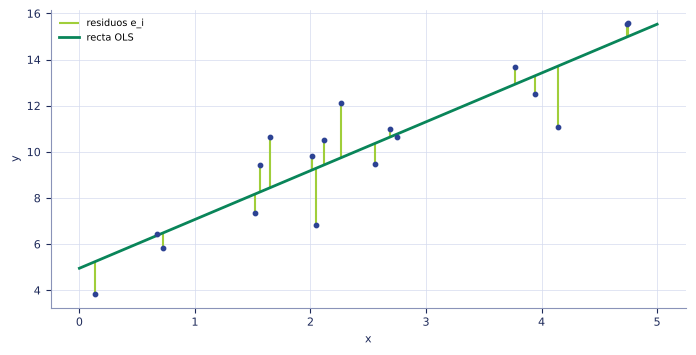

In [9]:
r=np.random.default_rng(1); x=r.uniform(0,5,18); y=4+2.5*x+r.normal(0,1.2,18); b=np.polyfit(x,y,1)
f,a=fig(); a.vlines(x,y,np.polyval(b,x),colors=LIME,lw=1.5,label="residuos e_i"); a.scatter(x,y,s=10,c=NAVY,zorder=3)
t=np.linspace(0,5,2); a.plot(t,np.polyval(b,t),c=GREEN,lw=2,label="recta OLS"); a.set_xlabel("x"); a.set_ylabel("y"); a.legend(); save(f,"f02.png")

## 03 · Descenso de gradiente
*Batch, estocástico y mini-batch: el puente hacia el deep learning*

- **Idea:** mover β en la dirección opuesta al gradiente de la pérdida.
- **Gradiente del MSE:** ∇J(β) = (2/n) Xᵀ(Xβ − y).
- **Actualización:** β ← β − η ∇J(β); η es la tasa de aprendizaje.
- **Batch:** usa todos los datos en cada paso; estable pero costoso con n grande.
- **SGD:** usa un ejemplo por paso; ruidoso pero barato y escalable.
- **Mini-batch:** usa lotes de 32–512 ejemplos; es el estándar en GPU.
- **Convexidad:** el MSE lineal es convexo: hay un único mínimo global.
- **Variantes:** momentum, Adam y AdamW son las mismas ideas aplicadas a redes profundas.

**Fórmulas clave:** `∇J = (2/n) Xᵀ(Xβ − y)` · `β ← β − η ∇J(β)`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Pérdida convexa y suave (MSE lineal) | Curva de pérdida monótona decreciente | Reducir η; revisar el gradiente |
| Tasa de aprendizaje estable | η < 2/λ_max(XᵀX/n); calcular λ_max | Escalar datos; η adaptativo (Adam) |
| Predictores escalados | Media ≈ 0 y desviación ≈ 1 por columna | StandardScaler dentro del Pipeline |
| Lotes representativos (SGD) | Barajar en cada época; varianza del gradiente | Lotes más grandes; shuffle |
| Convergencia real | ‖∇J‖ < tolerancia; comparar con la solución OLS | Más épocas, early stopping |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | Encontrar β sin la fórmula cerrada. |
| **Datos** | 500 datos, 2 predictores; β real = (1, 3, −2). |
| **Modelo** | Batch GD (η = 0.1, 200 épocas) y mini-batch (lote 32, 20 épocas). |
| **Resultado** | Ambos llegan a b = (0.93, 2.96, −2.01), igual que OLS. |
| **Interpretación** | Mini-batch alcanza el piso de error con 10× menos épocas. |

**Usos:** *Big data*: Regresión con millones de filas que no caben en memoria · *Streaming*: Actualizar el modelo con cada dato nuevo (online) · *Deep learning*: Mismo bucle para entrenar redes y LLM · *Publicidad*: Predecir CTR con miles de variables dispersas · *IoT*: Aprendizaje en dispositivos con poca memoria · *Federado*: Entrenar en celulares sin centralizar los datos

### Ejemplo en Python — GD desde cero vs. OLS

In [10]:
import numpy as np

rng = np.random.default_rng(2)
n = 500
X = np.column_stack([np.ones(n), rng.normal(0, 1, (n, 2))])
y = X @ np.array([1.0, 3.0, -2.0]) + rng.normal(0, 0.5, n)

def gd(X, y, lr=0.1, epocas=200, lote=None):
    w = np.zeros(X.shape[1])
    for _ in range(epocas):
        idx = rng.permutation(n) if lote else [np.arange(n)]
        for b in (np.array_split(idx, n // lote) if lote else idx):
            grad = 2 * X[b].T @ (X[b] @ w - y[b]) / len(b)   # ∇ MSE
            w -= lr * grad
    return w

print("Batch GD   :", np.round(gd(X, y), 3))
print("Mini-batch :", np.round(gd(X, y, lr=0.05, epocas=20, lote=32), 3))
print("OLS exacto :", np.round(np.linalg.lstsq(X, y, rcond=None)[0], 3))

Batch GD   : [ 0.931  2.961 -2.006]


Mini-batch : [ 0.925  2.978 -2.017]
OLS exacto : [ 0.931  2.961 -2.006]


**Qué observar**

- Ambas variantes llegan al b de OLS.
- Mini-batch usa 20 épocas en vez de 200.
- El gradiente es 2Xᵀ(Xw − y)/|lote|.

### Visualización

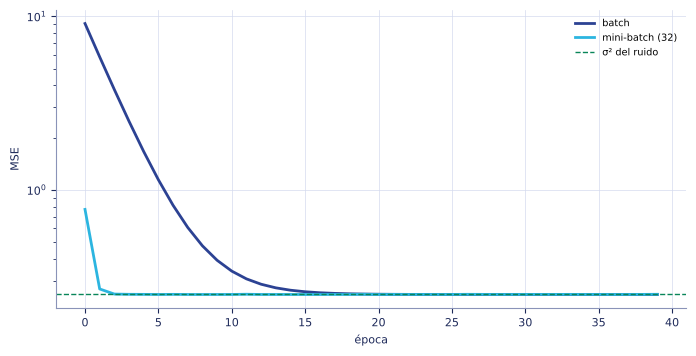

In [11]:
r=np.random.default_rng(2); n=500; X=np.c_[np.ones(n),r.normal(0,1,(n,2))]; y=X@[1,3,-2]+r.normal(0,.5,n)
def curve(lr,lote,ep):
    w=np.zeros(3); L=[]
    for _ in range(ep):
        idx=r.permutation(n); bs=np.array_split(idx,n//lote) if lote else [idx]
        for b_ in bs: w-=lr*2*X[b_].T@(X[b_]@w-y[b_])/len(b_)
        L.append(np.mean((X@w-y)**2))
    return L
f,a=fig(); a.plot(curve(.1,None,40),c=NAVY,lw=2,label="batch"); a.plot(curve(.05,32,40),c=CYAN,lw=2,label="mini-batch (32)")
a.axhline(.25,ls="--",c=GREEN,lw=1,label="σ² del ruido"); a.set_yscale("log"); a.set_xlabel("época"); a.set_ylabel("MSE"); a.legend(); save(f,"f03.png")

## 04 · Supuestos y diagnóstico
*Linealidad, homocedasticidad, normalidad, independencia y multicolinealidad*

- **Linealidad:** E[y | x] es lineal en β; se revisa con residuos vs. ajustados.
- **Independencia:** errores no correlacionados; se revisa con Durbin–Watson (≈ 2 es bueno).
- **Homocedasticidad:** Var(ε | x) constante; un embudo en los residuos indica lo contrario (Breusch–Pagan).
- **Normalidad:** ε ~ N(0, σ²), necesaria para intervalos exactos (Shapiro–Wilk, gráfico Q-Q).
- **Multicolinealidad:** predictores muy correlacionados inflan la varianza de b (VIF > 10).
- **Influencia:** puntos con alto apalancamiento o distancia de Cook alteran la recta.
- **Remedios:** transformar y (log), errores robustos (HC3), regularizar o quitar predictores redundantes.
- **Clave:** los supuestos importan para la inferencia; la predicción es más tolerante.

**Fórmulas clave:** `VIFⱼ = 1 / (1 − R²ⱼ)` · `DW = Σ(eₜ − eₜ₋₁)² / Σeₜ²`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Linealidad | RESET, Harvey–Collier, Rainbow + residuos vs. ajustados | Transformar / polinomios |
| Independencia | Durbin–Watson, Breusch–Godfrey, Ljung–Box + ACF | HAC, cluster, GLS |
| Homocedasticidad | Breusch–Pagan, White, Goldfeld–Quandt + escala–ubicación | HC3, WLS, log(y) |
| Normalidad | Shapiro–Wilk, Jarque–Bera, Anderson–Darling + Q-Q | Box-Cox, bootstrap |
| Colinealidad e influencia | VIF, κ(X); Cook > 4/n, |rᵢ| > 3, hᵢᵢ > 2(p+1)/n | Ridge; revisar o robustecer |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | ¿Son confiables los valores p de este modelo? |
| **Datos** | 300 obs.; varianza que crece con x₁; x₂ ≈ 0.9·x₁. |
| **Modelo** | OLS + pruebas BP, Shapiro–Wilk, DW y VIF. |
| **Resultado** | BP p ≈ 0; DW = 1.9; VIF = 20.2. |
| **Interpretación** | Hay heterocedasticidad y colinealidad: usar HC3 y quitar x₂. |

**Usos:** *Investigación*: Validar inferencias antes de publicar un artículo · *Regulación*: Auditar modelos de riesgo crediticio exigidos por ley · *Salud*: Estudios clínicos con covariables y pocos pacientes · *Economía*: Series de tiempo con autocorrelación en los errores · *Industria*: Control estadístico de procesos de producción · *Auditoría*: Revisar modelos heredados antes de reutilizarlos

### Ejemplo en Python — Pruebas de diagnóstico con statsmodels

In [12]:
import numpy as np, statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor as vif)

rng = np.random.default_rng(3)
n = 300
x1 = rng.uniform(1, 10, n)
x2 = 0.9 * x1 + rng.normal(0, 0.5, n)          # casi colineal con x1
y = 2 + 1.5 * x1 + 0.5 * x2 + rng.normal(0, 0.3 * x1)  # varianza crece con x1
X = sm.add_constant(np.column_stack([x1, x2]))
res = sm.OLS(y, X).fit()

print("Breusch-Pagan p :", round(het_breuschpagan(res.resid, X)[1], 4))
print("Shapiro-Wilk p  :", round(shapiro(res.resid).pvalue, 4))
print("Durbin-Watson   :", round(durbin_watson(res.resid), 2))
print("VIF x1, x2      :", [round(float(vif(X, i)), 1) for i in (1, 2)])

Breusch-Pagan p : 0.0
Shapiro-Wilk p  : 0.0002
Durbin-Watson   : 1.9
VIF x1, x2      : [20.2, 20.2]


**Qué observar**

- BP p < 0.05: varianza no constante.
- VIF = 20: x₁ y x₂ son redundantes.
- DW ≈ 1.9: sin autocorrelación.

### Visualización

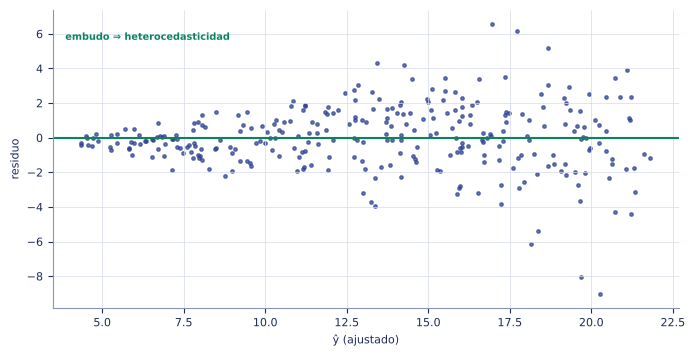

In [13]:
r=np.random.default_rng(3); x=r.uniform(1,10,300); y=2+2*x+r.normal(0,.3*x); b=np.polyfit(x,y,1); yh=np.polyval(b,x)
f,a=fig(); a.scatter(yh,y-yh,s=6,c=NAVY,alpha=.7); a.axhline(0,c=GREEN,lw=1.5); a.set_xlabel("ŷ (ajustado)"); a.set_ylabel("residuo")
a.text(.02,.9,"embudo ⇒ heterocedasticidad",transform=a.transAxes,color=GREEN,fontsize=7,weight="bold"); save(f,"f04.png")

## 05 · Métricas y validación
*MSE, RMSE, MAE, R², R² ajustado y validación cruzada*

- **MSE:** promedio de errores al cuadrado; penaliza fuerte los errores grandes.
- **RMSE:** √MSE; está en las mismas unidades que y.
- **MAE:** promedio de |error|; más robusto ante outliers.
- **R²:** 1 − SSE/SST; proporción de varianza explicada (puede ser < 0 en test).
- **R² ajustado:** penaliza agregar predictores: 1 − (1 − R²)(n − 1)/(n − p − 1).
- **Hold-out:** separar train/test antes de cualquier ajuste para evitar fuga de datos.
- **Validación cruzada k-fold:** promedia el desempeño en k particiones; reporta media ± desviación.
- **Línea base:** comparar siempre contra predecir la media de y.

**Fórmulas clave:** `R² = 1 − SSE / SST` · `RMSE = √( Σ(yᵢ − ŷᵢ)² / n )`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Train y test de la misma distribución | KS por variable; clasificador adversarial (AUC ≈ 0.5) | Reponderar o recolectar datos nuevos |
| Sin fuga de datos | Todo el preprocesamiento dentro del Pipeline; split primero | Rehacer el pipeline |
| Independencia entre pliegues | ¿Hay grupos o tiempo? Revisar el diseño | GroupKFold, TimeSeriesSplit |
| Comparación justa de modelos | Mismos pliegues; prueba pareada (t corregida de Nadeau–Bengio) | Repetir CV; reportar media ± DE |
| Métrica acorde al costo del error | MAE si hay outliers; RMSE si los errores grandes cuestan más | Reportar varias métricas |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | ¿Qué tan bien predice la progresión de la diabetes? |
| **Datos** | 442 pacientes, 10 variables clínicas. |
| **Modelo** | OLS; test del 25 % y validación cruzada de 5 pliegues. |
| **Resultado** | RMSE = 56.4, R² test = 0.36; R² CV = 0.48 ± 0.05. |
| **Interpretación** | Un solo split engaña: la CV da una estimación más estable. |

**Usos:** *Salud*: Comparar modelos de progresión de una enfermedad · *Energía*: Pronóstico de demanda eléctrica con validación temporal · *Retail*: Pronóstico de ventas por tienda y semana · *Competencias*: Seleccionar el mejor modelo sin sobreajustar al test · *Investigación*: Reportar un desempeño honesto (media ± DE) · *MLOps*: Detectar deriva cuando el error crece en producción

### Ejemplo en Python — Métricas en test y con CV

In [14]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X, y = load_diabetes(return_X_y=True)          # 442 pacientes, 10 variables
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0)
m = LinearRegression().fit(Xtr, ytr)
p = m.predict(Xte)

n, k = Xte.shape
r2 = r2_score(yte, p)
print("RMSE :", round(mean_squared_error(yte, p) ** 0.5, 2))
print("MAE  :", round(mean_absolute_error(yte, p), 2))
r2_aj = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print("R²   :", round(r2, 3), "| R² ajustado:", round(r2_aj, 3))
cv = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
print("R² CV-5: media", round(cv.mean(), 3), "± ", round(cv.std(), 3))

RMSE : 56.39
MAE  : 45.12
R²   : 0.359 | R² ajustado: 0.295
R² CV-5: media 0.482 ±  0.049


**Qué observar**

- RMSE está en unidades de y.
- R² ajustado < R² por los 10 predictores.
- CV da una estimación más estable.

### Visualización

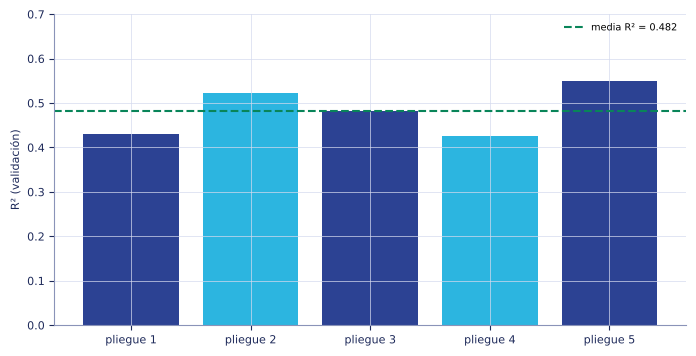

In [15]:
from sklearn.datasets import load_diabetes; from sklearn.model_selection import cross_val_score, cross_val_predict
Xd,yd=load_diabetes(return_X_y=True); cv=cross_val_score(LinearRegression(),Xd,yd,cv=5,scoring="r2")
f,a=fig(); a.bar([f"pliegue {i+1}" for i in range(5)],cv,color=[NAVY,CYAN,NAVY,CYAN,NAVY]); a.axhline(cv.mean(),c=GREEN,lw=1.5,ls="--",label=f"media R² = {cv.mean():.3f}")
a.set_ylim(0,.7); a.set_ylabel("R² (validación)"); a.legend(loc="upper right"); save(f,"f05.png")

## 06 · Características y sesgo–varianza
*Polinomios, interacciones, variables categóricas y escalado*

- **Expansión de bases:** φ(x) = (1, x, x², …) mantiene el modelo lineal en β pero curva la predicción.
- **Interacciones:** xᵢ·xⱼ modela efectos que dependen de otra variable.
- **Categóricas:** codificación one-hot con k − 1 dummies para evitar colinealidad perfecta.
- **Escalado:** estandarizar x es necesario para GD y regularización.
- **Sesgo:** error por un modelo demasiado simple (subajuste).
- **Varianza:** sensibilidad a la muestra de entrenamiento (sobreajuste).
- **Descomposición:** E[(y − ŷ)²] = sesgo² + varianza + σ² irreducible.
- **Selección:** elegir la complejidad (grado, nº de variables) por validación, no por error de entrenamiento.

**Fórmulas clave:** `ŷ = Σ βⱼ φⱼ(x)` · `Error = Sesgo² + Var + σ²`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Forma funcional correcta tras φ(x) | Gráficos de componente + residuo; RESET | Splines o más términos |
| Sin trampa de dummies | k − 1 dummies; rank(X) completo | drop='first' en OneHotEncoder |
| Complejidad elegida por validación | Curva de validación (error CV vs. grado) | Regularizar o reducir grado |
| Sin extrapolación fuera del rango | Rango de x en producción vs. entrenamiento | Splines naturales; limitar dominio |
| Escalado de términos polinomiales | VIF de x, x², x³ (suele ser alto) | Centrar y escalar; bases ortogonales |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | Ajustar una curva sin(2πx) con un modelo lineal. |
| **Datos** | 40 puntos con ruido N(0, 0.2²). |
| **Modelo** | Polinomios de grado 1, 3 y 15 + OLS. |
| **Resultado** | MSE test: 0.216 (g1), 0.006 (g3), 0.032 (g15). |
| **Interpretación** | Grado 3 equilibra sesgo y varianza; 15 sobreajusta. |

**Usos:** *Inmobiliario*: Precio con interacción área × zona · *Clima*: Tendencia no lineal de temperatura con polinomios · *Biología*: Curvas dosis–respuesta con términos cuadráticos · *Seguros*: Tarifas con variables categóricas (one-hot) · *Manufactura*: Superficie de respuesta para optimizar un proceso · *Deporte*: Rendimiento vs. edad: curva en forma de U invertida

### Ejemplo en Python — Subajuste, ajuste y sobreajuste

In [16]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mse

rng = np.random.default_rng(4)
x = np.sort(rng.uniform(0, 1, 40)); xt = np.linspace(0, 1, 200)
f = lambda t: np.sin(2 * np.pi * t)
y = f(x) + rng.normal(0, 0.2, 40)

for g in (1, 3, 15):                          # sub-ajuste, ajuste, sobre-ajuste
    m = make_pipeline(PolynomialFeatures(g), StandardScaler(),
                      LinearRegression())
    m.fit(x[:, None], y)
    tr = mse(y, m.predict(x[:, None]))
    te = mse(f(xt), m.predict(xt[:, None]))
    print(f"grado {g:>2}: MSE train={tr:.3f}  MSE test={te:.3f}")

grado  1: MSE train=0.166  MSE test=0.216
grado  3: MSE train=0.033  MSE test=0.006
grado 15: MSE train=0.029  MSE test=0.032


**Qué observar**

- El error de train siempre baja con el grado.
- El error de test tiene forma de U.
- El mismo modelo lineal, distinta φ(x).

### Visualización

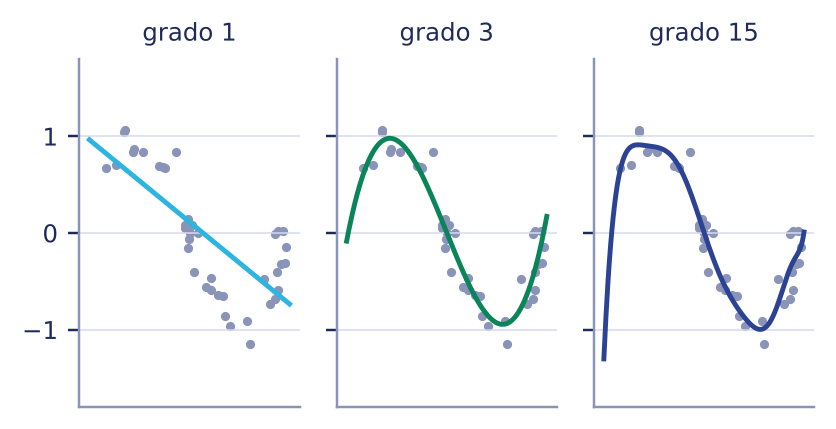

In [17]:
r=np.random.default_rng(4); x=np.sort(r.uniform(0,1,40)); y=np.sin(2*np.pi*x)+r.normal(0,.2,40); t=np.linspace(0,1,300)
f,ax=plt.subplots(1,3,figsize=(3.84,1.99),dpi=220,sharey=True)
for a,g,c in zip(ax,(1,3,15),(CYAN,GREEN,NAVY)):
    m=make_pipeline(PolynomialFeatures(g),StandardScaler(),LinearRegression()).fit(x[:,None],y)
    a.scatter(x,y,s=4,c="#8A93B8"); a.plot(t,m.predict(t[:,None]),c=c,lw=1.6); a.set_title(f"grado {g}",fontsize=8,color=INK); a.set_ylim(-1.8,1.8); a.set_xticks([])
save(f,"f06.png")

---
# Bloque B · Variantes modernas
*Regularización, robustez, enfoque bayesiano, incertidumbre e interpretación*

## 07 · Regularización
*Ridge (L2), Lasso (L1) y Elastic Net*

- **Problema:** con p grande o colinealidad, b de OLS tiene varianza alta.
- **Ridge (L2):** minimiza ‖y − Xβ‖² + α‖β‖²₂; encoge todos los coeficientes.
- **Solución Ridge:** b = (XᵀX + αI)⁻¹Xᵀy; siempre invertible.
- **Lasso (L1):** penaliza α‖β‖₁; lleva coeficientes exactamente a cero (selección).
- **Elastic Net:** mezcla L1 y L2; estable con predictores correlacionados.
- **Hiperparámetro α:** controla el sesgo–varianza; se elige por validación cruzada.
- **Escalado obligatorio:** la penalización depende de la escala de cada xⱼ.
- **Conexión LLM:** weight decay en AdamW es regularización L2 en redes.

**Fórmulas clave:** `Ridge: ‖y − Xβ‖² + α‖β‖²` · `Lasso: ‖y − Xβ‖² + α‖β‖₁`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Supuestos de OLS salvo colinealidad | Mismo diagnóstico de residuos (BP, DW, Q-Q) | HC3, transformaciones |
| Predictores en la misma escala | Media 0 y DE 1 antes de penalizar | StandardScaler en Pipeline |
| α adecuado | Curva de validación; RidgeCV / LassoCV | Grid más amplio, CV repetida |
| Lasso: esparsidad y estabilidad | Stability selection (bootstrap de la selección) | Elastic Net con grupos correlacionados |
| Inferencia post-selección | No usar valores p ingenuos tras Lasso | Bootstrap, inferencia selectiva |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | Reducir la varianza y seleccionar variables. |
| **Datos** | Diabetes estandarizado, 10 predictores. |
| **Modelo** | OLS vs. Ridge (α = 50) vs. Lasso (α = 5) vs. Elastic Net; LassoCV. |
| **Resultado** | ‖b‖ baja de 65.5 a 34.6; Lasso deja 5 coef. ≠ 0; α* = 0.079. |
| **Interpretación** | Lasso descarta 5 variables con poca pérdida de ajuste. |

**Usos:** *Genómica*: Miles de genes y pocos pacientes: Lasso selecciona genes · *Finanzas*: Factores de riesgo correlacionados: Ridge estabiliza · *Texto*: Regresión sobre miles de columnas TF-IDF · *Marketing*: Mix de medios con canales colineales · *Neurociencia*: Decodificar estímulos desde señales fMRI · *LLM*: Probes lineales sobre activaciones de alta dimensión

### Ejemplo en Python — OLS vs. Ridge vs. Lasso vs. Elastic Net

In [18]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                  ElasticNet, LassoCV)

X, y = load_diabetes(return_X_y=True)
X = StandardScaler().fit_transform(X)          # regularizar exige escalar

modelos = {"OLS": LinearRegression(), "Ridge α=50": Ridge(alpha=50),
           "Lasso α=5": Lasso(alpha=5),
           "ElasticNet": ElasticNet(alpha=1, l1_ratio=0.5)}
for nombre, m in modelos.items():
    c = m.fit(X, y).coef_
    nz = np.sum(np.abs(c) > 1e-6)
    print(f"{nombre:11s} ‖β‖₂={np.linalg.norm(c):6.1f}  coef≠0: {nz}")

cv = LassoCV(cv=5, random_state=0).fit(X, y)
print("LassoCV α* =", round(cv.alpha_, 3))

OLS         ‖β‖₂=  65.5  coef≠0: 10
Ridge α=50  ‖β‖₂=  37.6  coef≠0: 10
Lasso α=5   ‖β‖₂=  34.6  coef≠0: 5
ElasticNet  ‖β‖₂=  29.3  coef≠0: 10
LassoCV α* = 0.079


**Qué observar**

- Ridge reduce ‖β‖ sin anular coeficientes.
- Lasso anula 5 de 10 coeficientes.
- LassoCV elige α automáticamente.

### Visualización

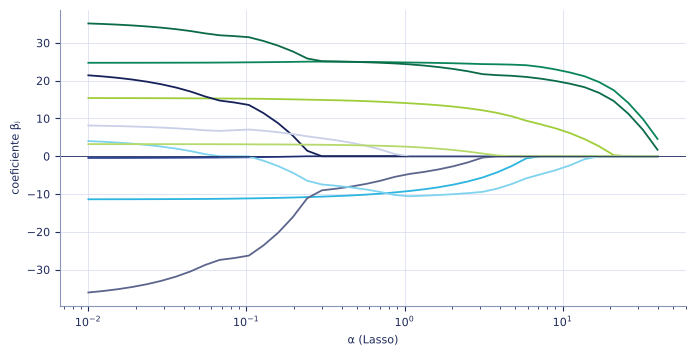

In [19]:
Xs=StandardScaler().fit_transform(Xd); al=np.logspace(-2,1.6,40); C=np.array([Lasso(alpha=v,max_iter=20000).fit(Xs,yd).coef_ for v in al])
f,a=fig(); cols=[NAVY,CYAN,GREEN,LIME,"#5D658C","#17225A","#7FD3EE","#C9D0E8","#0B6B47","#B5DA6B"]
for j in range(10): a.plot(al,C[:,j],c=cols[j],lw=1.3)
a.set_xscale("log"); a.set_xlabel("α (Lasso)"); a.set_ylabel("coeficiente βⱼ"); a.axhline(0,c=INK,lw=.6); save(f,"f07.png")

## 08 · Regresión robusta y cuantílica
*Huber, RANSAC y regresión por cuantiles*

- **Problema:** el cuadrado del MSE hace que pocos outliers arrastren la recta.
- **Pérdida de Huber:** cuadrática para errores pequeños y lineal para grandes (umbral δ).
- **RANSAC:** ajusta con subconjuntos aleatorios y conserva el consenso de inliers.
- **Theil–Sen:** mediana de pendientes entre pares; robusto hasta ~29 % de contaminación.
- **Regresión cuantílica:** estima el cuantil τ de y | x minimizando la pérdida pinball.
- **Mediana (τ = 0.5):** equivale a minimizar el error absoluto (MAE).
- **Bandas τ = 0.1 y 0.9:** describen cómo cambia la dispersión con x (heterocedasticidad).
- **Punto de quiebre:** fracción de datos contaminados que tolera el estimador.

**Fórmulas clave:** `ρ_τ(u) = u·(τ − 1[u < 0])` · `Huber: ½u² si |u| ≤ δ; δ|u| − ½δ²`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Huber: outliers en y, no en x | Apalancamiento hᵢᵢ y residuos studentizados | RANSAC o estimadores MM |
| RANSAC: mayoría de inliers (> 50 %) | Proporción de inliers y estabilidad entre semillas | Ajustar residual_threshold |
| Cuantílica: cuantil lineal en x | Cobertura empírica: fracción de y bajo ŷ_τ ≈ τ | Términos no lineales |
| Cuantiles que no se cruzan | Comprobar ŷ₀.₁ ≤ ŷ₀.₅ ≤ ŷ₀.₉ en todo x | Reordenar o ajuste conjunto |
| Independencia de observaciones | Durbin–Watson sobre residuos | Bootstrap por bloques |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | Estimar la pendiente con datos contaminados. |
| **Datos** | 100 puntos, pendiente real 1, 6 outliers con alto apalancamiento. |
| **Modelo** | OLS vs. Huber vs. RANSAC; cuantiles 0.1 / 0.5 / 0.9. |
| **Resultado** | OLS 0.32 · Huber 0.85 · RANSAC 0.92; cuantiles 0.86 / 0.95 / 1.17. |
| **Interpretación** | Los robustos resisten; los cuantiles muestran varianza creciente. |

**Usos:** *Sensores*: Lecturas con fallas esporádicas: Huber ignora los picos · *Visión*: RANSAC estima geometría con puntos mal emparejados · *Finanzas*: Value-at-Risk con el cuantil 5 % de pérdidas · *Salud*: Curvas de crecimiento infantil por percentiles · *Energía*: Bandas p10–p90 de demanda · *Logística*: Tiempo de entrega p90 para prometer fechas

### Ejemplo en Python — Outliers y cuantiles

In [20]:
import numpy as np
from sklearn.linear_model import (LinearRegression, HuberRegressor,
                                  RANSACRegressor, QuantileRegressor)

rng = np.random.default_rng(5)
x = rng.uniform(0, 10, 100)
y = 2 + 1.0 * x + rng.normal(0, 0.3 + 0.15 * x)    # verdad: pendiente = 1
y0 = y.copy(); i = np.argsort(x)[-6:]; y[i] -= 20  # 6 outliers
X = x[:, None]

for nombre, m in {"OLS": LinearRegression(), "Huber": HuberRegressor(),
                  "RANSAC": RANSACRegressor(random_state=0)}.items():
    m.fit(X, y)
    b = m.estimator_.coef_[0] if nombre == "RANSAC" else m.coef_[0]
    print(f"{nombre:6s} pendiente = {b:.3f}")

for q in (0.1, 0.5, 0.9):                    # datos limpios
    qr = QuantileRegressor(quantile=q, alpha=0, solver="highs").fit(X, y0)
    print(f"cuantil {q}: pendiente = {qr.coef_[0]:.3f}")

OLS    pendiente = 0.322
Huber  pendiente = 0.854
RANSAC pendiente = 0.922
cuantil 0.1: pendiente = 0.862
cuantil 0.5: pendiente = 0.953
cuantil 0.9: pendiente = 1.170


**Qué observar**

- OLS se desvía mucho por solo 6 puntos.
- Huber y RANSAC recuperan una pendiente cercana a 1.
- Pendientes de cuantiles distintas ⇒ varianza creciente.

### Visualización

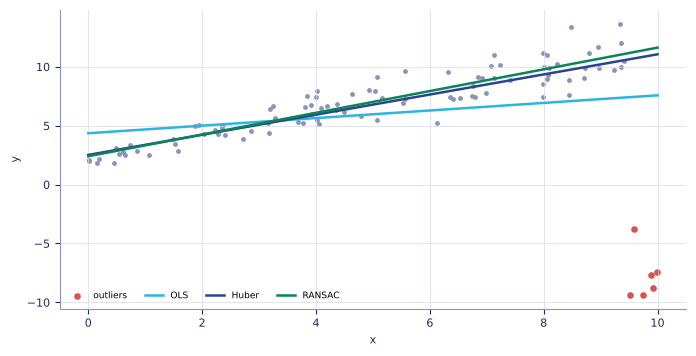

In [21]:
r=np.random.default_rng(5); x=r.uniform(0,10,100); y=2+x+r.normal(0,.3+.15*x); i=np.argsort(x)[-6:]; y[i]-=20; X=x[:,None]; t=np.linspace(0,10,2)[:,None]
f,a=fig(); a.scatter(x,y,s=6,c="#8A93B8"); a.scatter(x[i],y[i],s=14,c="#D9534F",label="outliers")
for m,c,l in ((LinearRegression(),CYAN,"OLS"),(HuberRegressor(),NAVY,"Huber"),(RANSACRegressor(random_state=0),GREEN,"RANSAC")):
    a.plot(t,m.fit(X,y).predict(t),c=c,lw=1.8,label=l)
a.legend(ncol=4,loc="lower left",fontsize=6.5); a.set_xlabel("x"); a.set_ylabel("y"); save(f,"f08.png")

## 09 · Regresión lineal bayesiana
*Prior, posterior y predicción con incertidumbre*

- **Prior:** creencia previa sobre β, por ejemplo β ~ N(0, α⁻¹I).
- **Verosimilitud:** y | X, β ~ N(Xβ, σ²I).
- **Posterior:** β | datos ~ N(m, S) con S = (αI + XᵀX/σ²)⁻¹ y m = S Xᵀy / σ².
- **MAP = Ridge:** la media posterior con prior gaussiano coincide con Ridge con λ = ασ².
- **Predictiva:** Var[ŷ(x)] = σ² + xᵀSx; crece lejos de los datos.
- **Pocos datos:** el prior regulariza; con muchos datos domina la verosimilitud.
- **Evidencia:** permite elegir α y σ² sin validación cruzada (BayesianRidge, ARD).
- **AIMA:** conecta con el razonamiento probabilístico y el aprendizaje bayesiano (cap. 12–13, 20).

**Fórmulas clave:** `p(β | y) ∝ p(y | β) · p(β)` · `Var[ŷ*] = σ² + x*ᵀ S x*`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Verosimilitud gaussiana adecuada | Posterior predictive checks (simular y comparar) | Verosimilitud t-Student |
| Prior razonable | Prior predictive checks; análisis de sensibilidad al prior | Priors débilmente informativos |
| Convergencia del muestreo (MCMC) | R̂ < 1.01, ESS > 400, trazas mezcladas | Más iteraciones, reparametrizar |
| Calibración de la incertidumbre | Cobertura de intervalos creíbles en test; histograma PIT uniforme | Revisar ruido y prior |
| Selección de modelos | LOO-CV (PSIS) o WAIC | Promediar modelos |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | Estimar β y su incertidumbre con pocos datos. |
| **Datos** | 15 puntos de y = 0.5 + 1.2x + ruido. |
| **Modelo** | Prior N(0, I), posterior gaussiano cerrado; BayesianRidge. |
| **Resultado** | b₁ = 1.27 ± 0.11; ŷ(0) = 0.51 ± 0.86; ŷ(6) = 8.15 ± 1.11. |
| **Interpretación** | La incertidumbre crece al extrapolar fuera de los datos. |

**Usos:** *Medicina*: Ensayos con pocos pacientes y conocimiento previo · *A/B testing*: Efecto de un cambio con intervalos creíbles · *Optimización*: Base de la optimización bayesiana de hiperparámetros · *Ciencia*: Calibrar modelos físicos con mediciones escasas · *Marketing*: Media mix bayesiano con priors por canal · *Robótica*: Modelos dinámicos que cuantifican incertidumbre

### Ejemplo en Python — Posterior cerrado y BayesianRidge

In [22]:
import numpy as np
from sklearn.linear_model import BayesianRidge

rng = np.random.default_rng(6)
x = rng.uniform(-3, 3, 15)                 # pocos datos
y = 0.5 + 1.2 * x + rng.normal(0, 0.8, 15)
X = np.column_stack([np.ones(15), x])

alpha, sigma2 = 1.0, 0.8 ** 2              # prior N(0, α⁻¹I), ruido σ²
S = np.linalg.inv(alpha * np.eye(2) + X.T @ X / sigma2)  # cov. posterior
m = S @ X.T @ y / sigma2                   # media posterior (= Ridge)
print("Media posterior β :", np.round(m, 3))
print("Desv. posterior β :", np.round(np.sqrt(np.diag(S)), 3))

br = BayesianRidge().fit(x[:, None], y)
mu, sd = br.predict([[0.0], [6.0]], return_std=True)
print("Predicción x=0:", round(mu[0], 2), "±", round(sd[0], 2))
print("Predicción x=6:", round(mu[1], 2), "±", round(sd[1], 2), "(extrapola)")

Media posterior β : [0.489 1.269]
Desv. posterior β : [0.203 0.11 ]
Predicción x=0: 0.51 ± 0.86
Predicción x=6: 8.15 ± 1.11 (extrapola)


**Qué observar**

- La media posterior equivale a Ridge.
- La desviación indica cuánto sabemos de β.
- La incertidumbre aumenta al extrapolar.

### Visualización

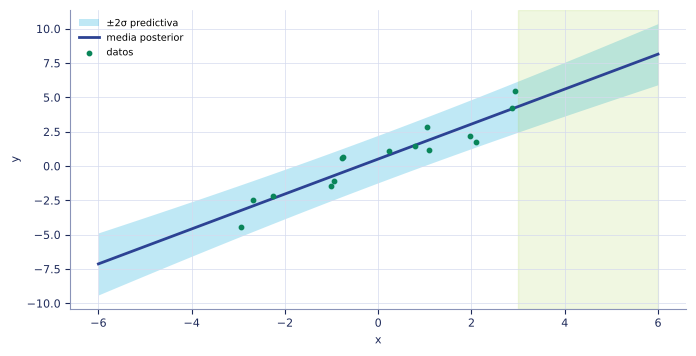

In [23]:
r=np.random.default_rng(6); x=r.uniform(-3,3,15); y=.5+1.2*x+r.normal(0,.8,15); br=BayesianRidge().fit(x[:,None],y); t=np.linspace(-6,6,200)
mu,sd=br.predict(t[:,None],return_std=True)
f,a=fig(); a.fill_between(t,mu-2*sd,mu+2*sd,color=CYAN,alpha=.3,lw=0,label="±2σ predictiva"); a.plot(t,mu,c=NAVY,lw=2,label="media posterior"); a.scatter(x,y,s=10,c=GREEN,zorder=3,label="datos")
a.axvspan(3,6,color=LIME,alpha=.15); a.legend(loc="upper left"); a.set_xlabel("x"); a.set_ylabel("y"); save(f,"f09.png")

## 10 · Intervalos y predicción conforme
*Cuantificar la incertidumbre sin suponer normalidad*

- **Intervalo de confianza:** incertidumbre sobre la media E[y | x].
- **Intervalo de predicción:** incertidumbre sobre un y nuevo; siempre más ancho.
- **Clásico:** ŷ ± t·s·√(1 + xᵀ(XᵀX)⁻¹x); exige normalidad y homocedasticidad.
- **Predicción conforme:** garantiza cobertura ≥ 1 − α con solo suponer intercambiabilidad.
- **Split conformal:** entrenar, calibrar con residuos |yᵢ − ŷᵢ| y usar su cuantil q.
- **Agnóstico al modelo:** funciona igual con OLS, árboles, redes o LLM.
- **CQR:** conformalizar la regresión cuantílica da intervalos adaptativos.
- **Límite:** la garantía es marginal, no condicional a cada x.

**Fórmulas clave:** `q = Quantil_{⌈(n+1)(1−α)⌉/n}(|yᵢ − ŷᵢ|)` · `P(y ∈ ŷ ± q) ≥ 1 − α`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Intercambiabilidad calibración–test | Pruebas de cambio de distribución (KS, adversarial); orden temporal | Conformal ponderado o adaptativo (ACI) |
| Calibración separada del entrenamiento | Conjuntos disjuntos verificados | CV+ o Jackknife+ |
| Cobertura marginal ≥ 1 − α | Cobertura empírica en test con IC binomial | Revisar cuantil corregido |
| Cobertura por subgrupos | Cobertura condicional por grupo o rango de x | Mondrian conformal, CQR |
| Tamaño de calibración suficiente | Varianza de la cobertura ~ Beta; n_cal ≥ 500 recomendado | Más datos de calibración |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | Intervalos al 90 % sin suponer normalidad. |
| **Datos** | Ruido t-Student (colas pesadas); 500 train, 1.000 calibración. |
| **Modelo** | OLS + split conformal con |yᵢ − ŷᵢ|. |
| **Resultado** | Radio q = 2.43; cobertura en 5.000 puntos = 0.902. |
| **Interpretación** | La garantía se cumple aunque el ruido no sea normal. |

**Usos:** *Energía*: Bandas de pronóstico de carga con cobertura garantizada · *Salud*: Rango de días de estancia hospitalaria · *Finanzas*: Riesgo de una predicción de precio · *Manufactura*: Tolerancias de calidad para una medida · *Clasificación*: Conjuntos de etiquetas con garantía de cobertura · *Autónomos*: Abstenerse cuando el intervalo es demasiado ancho

### Ejemplo en Python — Split conformal desde cero

In [24]:
import numpy as np
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(7)
def datos(n):
    x = rng.uniform(0, 10, n)
    return x[:, None], 3 + 2 * x + rng.standard_t(3, n)  # colas pesadas

Xtr, ytr = datos(500); Xcal, ycal = datos(1000); Xte, yte = datos(5000)
m = LinearRegression().fit(Xtr, ytr)

alpha = 0.10                                   # objetivo: 90 % de cobertura
s = np.abs(ycal - m.predict(Xcal))             # puntajes de no conformidad
q = np.quantile(s, np.ceil((len(s) + 1) * (1 - alpha)) / len(s))
p = m.predict(Xte)
cobertura = np.mean((yte >= p - q) & (yte <= p + q))
print("Radio del intervalo q :", round(q, 3))
print("Cobertura empírica    :", round(cobertura, 3))

Radio del intervalo q : 2.426
Cobertura empírica    : 0.902


**Qué observar**

- Sin suponer normalidad del ruido.
- La cobertura queda cerca del 90 % objetivo.
- q es el cuantil de los residuos de calibración.

### Visualización

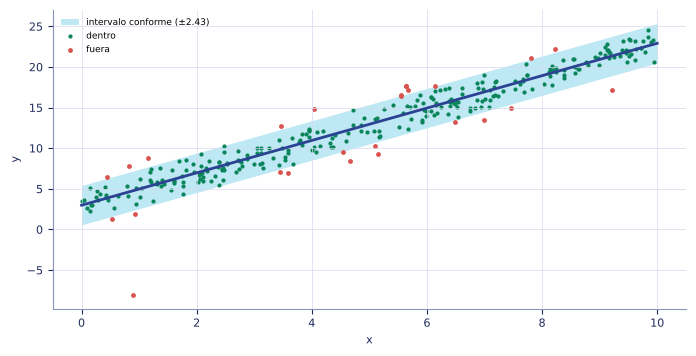

In [25]:
r=np.random.default_rng(7)
def dat(n): x=r.uniform(0,10,n); return x[:,None],3+2*x+r.standard_t(3,n)
Xt,yt=dat(500);Xc,yc=dat(1000);Xe,ye=dat(300); m=LinearRegression().fit(Xt,yt); s=np.abs(yc-m.predict(Xc)); q=np.quantile(s,np.ceil(1001*.9)/1000)
t=np.linspace(0,10,2)[:,None]; p=m.predict(t); pe=m.predict(Xe); inn=np.abs(ye-pe)<=q
f,a=fig(); a.fill_between(t[:,0],p-q,p+q,color=CYAN,alpha=.3,lw=0,label=f"intervalo conforme (±{q:.2f})"); a.plot(t,p,c=NAVY,lw=2)
a.scatter(Xe[inn,0],ye[inn],s=4,c=GREEN,label="dentro"); a.scatter(Xe[~inn,0],ye[~inn],s=6,c="#D9534F",label="fuera"); a.legend(loc="upper left",fontsize=6.5); a.set_xlabel("x"); a.set_ylabel("y"); save(f,"f10.png")

## 11 · Interpretabilidad y causalidad
*Coeficientes, SHAP lineal y confusores*

- **Coeficiente βⱼ:** cambio esperado en y por +1 en xⱼ, manteniendo el resto constante.
- **Coeficientes estandarizados:** permiten comparar importancia entre variables con escalas distintas.
- **SHAP lineal:** φⱼ = βⱼ(xⱼ − E[xⱼ]); reparte exactamente ŷ − E[ŷ] entre las variables.
- **Correlación ≠ causalidad:** un βⱼ ≠ 0 no implica que xⱼ cause y.
- **Confusor:** variable que afecta a x y a y a la vez; omitirla sesga βⱼ.
- **Ajuste por confusores:** incluirlos en la regresión bloquea el camino espurio (criterio de puerta trasera).
- **Colisionador:** ajustar por una consecuencia común crea asociaciones falsas.
- **Herramientas:** DAG causales, variables instrumentales, diferencias en diferencias.

**Fórmulas clave:** `φⱼ = βⱼ (xⱼ − E[xⱼ])` · `Σ φⱼ = ŷ − E[ŷ]`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Sin confusores no medidos | DAG; análisis de sensibilidad (E-value, Cinelli–Hazlett) | VI, diseño experimental |
| No ajustar por colisionadores ni mediadores | Criterio de puerta trasera sobre el DAG | Redefinir el conjunto de ajuste |
| Positividad (solapamiento) | Distribución de x por grupos de confusores | Restringir la población |
| SHAP lineal: predictores independientes | Correlación entre predictores | SHAP condicional; interpretar con cautela |
| Especificación correcta | Residuos vs. ajustados; RESET | Transformaciones, interacciones |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | ¿Las ventas de helado causan incidentes en la playa? |
| **Datos** | 1.000 días: temperatura, helados, incidentes. |
| **Modelo** | Regresión sin y con la temperatura como confusor. |
| **Resultado** | b_helados: 0.043 → 0.005 al ajustar; b_temp = 0.48. |
| **Interpretación** | La asociación era espuria: la temperatura causa ambos. |

**Usos:** *Políticas*: Evaluar el efecto de un programa social · *Salud*: Efecto de un tratamiento ajustando por confusores · *Crédito*: Explicar decisiones automáticas (exigencia regulatoria) · *Marketing*: Atribuir ventas a cada campaña · *RR. HH.*: Auditar brechas salariales ajustadas · *XAI*: Explicar predicciones con SHAP lineal

### Ejemplo en Python — Confusor y SHAP lineal

In [26]:
import numpy as np
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(8)
n = 1000
temp = rng.normal(28, 4, n)                         # confusor: temperatura
helados = 10 * temp + rng.normal(0, 20, n)          # ventas de helado
ahogados = 0.5 * temp + rng.normal(0, 1.5, n)       # incidentes en playa

m1 = LinearRegression().fit(helados[:, None], ahogados)
m2 = LinearRegression().fit(np.column_stack([helados, temp]), ahogados)
print("Solo helados      : β_helados =", round(m1.coef_[0], 4))
print("Ajustando por temp: β_helados =", round(m2.coef_[0], 4),
      "| β_temp =", round(m2.coef_[1], 3))

F = np.column_stack([helados, temp])
Z = (F - F.mean(0)) / F.std(0)                      # estandarizar
c = LinearRegression().fit(Z, ahogados).coef_
phi = c * Z[0]                                   # φⱼ = βⱼ(zⱼ − E[zⱼ])
print("SHAP lineal (obs. 0):", np.round(phi, 3))

Solo helados      : β_helados = 0.0433
Ajustando por temp: β_helados = 0.0047 | β_temp = 0.477
SHAP lineal (obs. 0): [-0.206 -3.258]


**Qué observar**

- β_helados casi desaparece al ajustar.
- La temperatura explica ambos fenómenos.
- SHAP lineal suma la desviación de ŷ.

### Visualización

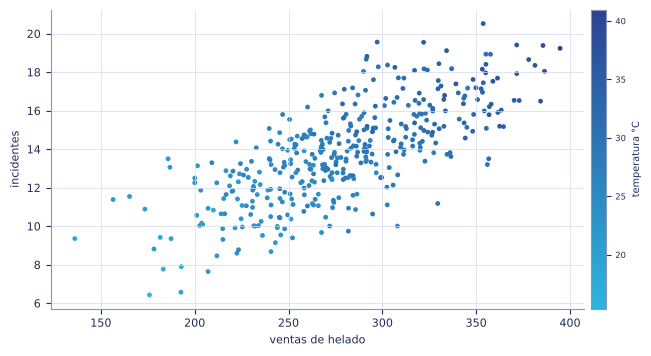

In [27]:
r=np.random.default_rng(8); n=400; T=r.normal(28,4,n); h=10*T+r.normal(0,20,n); d=.5*T+r.normal(0,1.5,n)
f,a=fig(); sc=a.scatter(h,d,c=T,cmap=matplotlib.colors.LinearSegmentedColormap.from_list("u",[CYAN,NAVY]),s=6); cb=f.colorbar(sc,ax=a,pad=.01); cb.set_label("temperatura °C",fontsize=7); cb.ax.tick_params(labelsize=6)
a.set_xlabel("ventas de helado"); a.set_ylabel("incidentes"); save(f,"f11.png")

---
# Bloque C · Regresión lineal en la era de los LLM
*Embeddings, probing, in-context learning, LLM regresores y leyes de escala*

## 12 · Embeddings + regresión
*Predecir un número a partir de texto*

- **Regresión sobre texto:** y es numérico (nota, precio, puntaje) y x es un texto.
- **Embedding:** un modelo de lenguaje convierte el texto en un vector h ∈ ℝᵈ (d = 384–4096).
- **Cabeza lineal:** ŷ = wᵀh + b, entrenada con Ridge sobre los embeddings congelados.
- **Ventaja:** pocos parámetros, rápido, reproducible y fácil de auditar.
- **Alta dimensión:** d grande frente a n exige regularización (Ridge o PCA previo).
- **Calidad del embedding:** importa más que el regresor; se compara con TF-IDF como línea base.
- **Variante:** fine-tuning completo o LoRA con cabeza de regresión cuando hay muchos datos.
- **Evaluación:** RMSE, MAE y correlación de Spearman con validación cruzada.

**Fórmulas clave:** `h = Encoder(texto)` · `ŵ = argmin ‖y − Hw‖² + λ‖w‖²`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| El embedding contiene la señal linealmente | Comparar con TF-IDF y con un embedding aleatorio | Otro encoder o fine-tuning |
| Sin duplicados entre train y test | Deduplicar por similitud coseno > 0.95 | Split por grupo o autor |
| Encoder adecuado al dominio e idioma | Error por subgrupo (idioma, longitud) | Encoder multilingüe o de dominio |
| d ≫ n controlado | Error train vs. CV; RidgeCV | Regularizar, PCA |
| Residuos estables para intervalos | Escala–ubicación de residuos | Intervalos conformes |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | Predecir la nota de una reseña a partir del texto. |
| **Datos** | 400 reseñas sintéticas con nota de 1 a 5. |
| **Modelo** | TF-IDF → SVD (8 dims) → RidgeCV. |
| **Resultado** | R² CV-5 = 0.94; ŷ(3 positivas + 1 negativa) = 4.13. |
| **Interpretación** | Un modelo lineal sobre vectores de texto predice bien. |

**Usos:** *Reseñas*: y: calificación 1–5 · x: texto de la reseña · *Educación*: y: puntaje de un ensayo · x: texto del estudiante · *Inmobiliario*: y: precio · x: descripción del anuncio · *RR. HH.*: y: salario · x: texto de la oferta laboral · *Salud*: y: severidad · x: notas clínicas · *Soporte*: y: horas de resolución · x: texto del ticket

### Ejemplo en Python — Texto → vector → regresión lineal

In [28]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(9)
pos = ["excelente", "rápido", "amable", "delicioso"]
neg = ["lento", "frío", "caro", "sucio"]
textos, notas = [], []
for _ in range(400):                                  # reseñas sintéticas
    k = rng.integers(0, 5)                     # nº de palabras positivas
    w = list(rng.choice(pos, k)) + list(rng.choice(neg, 4 - k))
    textos.append("el servicio fue " + " y ".join(rng.permutation(w)))
    notas.append(1 + k + rng.normal(0, 0.3))   # nota de 1 a 5

# "embedding" local: TF-IDF + SVD (se puede sustituir por un encoder)
modelo = make_pipeline(TfidfVectorizer(), TruncatedSVD(8, random_state=0),
                       RidgeCV())
r2 = cross_val_score(modelo, textos, notas, cv=5, scoring="r2")
print("R² CV-5:", round(r2.mean(), 3))
nueva = "el servicio fue excelente y amable y rápido y caro"
modelo.fit(textos, notas)
print("ŷ(nueva reseña):", round(modelo.predict([nueva])[0], 2))

R² CV-5: 0.941
ŷ(nueva reseña): 4.13


**Qué observar**

- El pipeline completo se evalúa con CV.
- Cambiar el vectorizador por un encoder LLM es una línea.
- La nota predicha es continua, no una clase.

### Visualización

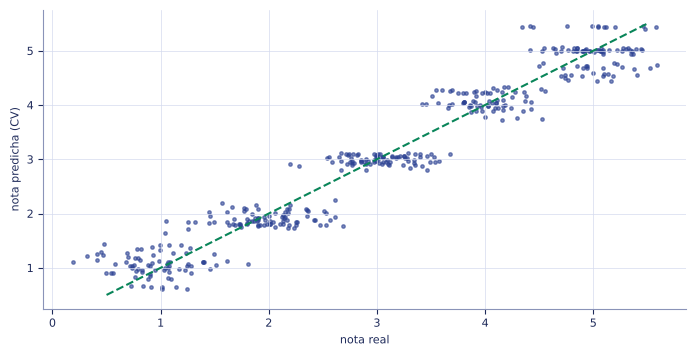

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer; from sklearn.decomposition import TruncatedSVD
mod=make_pipeline(TfidfVectorizer(),TruncatedSVD(8,random_state=0),RidgeCV()); pr=cross_val_predict(mod,textos,notas,cv=5)
f,a=fig(); a.scatter(notas,pr,s=6,c=NAVY,alpha=.6); a.plot([0.5,5.5],[0.5,5.5],c=GREEN,lw=1.5,ls="--"); a.set_xlabel("nota real"); a.set_ylabel("nota predicha (CV)"); save(f,"f12.png")

## 13 · Probing lineal
*La hipótesis de representación lineal en LLM*

- **Probe lineal:** regresión (o clasificación) lineal que lee una propiedad desde las activaciones h de un LLM.
- **Pregunta:** ¿la capa ℓ codifica linealmente la propiedad z (tiempo, lugar, sentimiento, veracidad)?
- **Hipótesis de representación lineal:** los conceptos se representan como direcciones en el espacio de activaciones.
- **Control:** comparar con etiquetas aleatorias o con un modelo sin entrenar (selectividad).
- **Por capas:** graficar R² del probe por capa muestra dónde aparece la información.
- **Dirección:** el vector w del probe se usa para intervenir el modelo (steering).
- **Cuidado:** que se pueda decodificar no implica que el modelo lo use.
- **Regularización:** d grande ⇒ Ridge con CV para no sobreajustar el probe.

**Fórmulas clave:** `ẑ = wᵀ h_ℓ + b` · `h ≈ h₀ + z·u  (dirección u)`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| La propiedad es lineal en h | Comparar probe lineal vs. MLP pequeño | Reportar ambos; no forzar linealidad |
| Selectividad del probe | Control tasks (Hewitt y Liang, 2019); etiquetas al azar | Más regularización, menos capacidad |
| Decodificable ≠ usado por el modelo | Intervenciones: steering o ablación de la dirección | Afirmar solo correlación |
| Splits sin fuga entre frases | Separar por plantilla o entidad | Re-particionar |
| Robustez entre capas y semillas | R² por capa con varias semillas | Reportar IC por capa |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | ¿Una propiedad está codificada linealmente? |
| **Datos** | 600 vectores de 256 dims con una dirección u oculta. |
| **Modelo** | Probe RidgeCV + control con etiquetas al azar. |
| **Resultado** | R² probe = 0.67; control = −0.10; cos(w, u) = 0.87. |
| **Interpretación** | El probe recupera la dirección del concepto, no ruido. |

**Usos:** *Interpretabilidad*: Saber qué información guarda cada capa · *Seguridad*: Detectar señales internas de engaño o sesgo · *Steering*: Modificar el comportamiento usando la dirección del probe · *Calidad*: Predecir si el modelo acertará antes de responder · *Investigación*: Comparar arquitecturas y capas · *Auditoría*: Hallar atributos sensibles codificados

### Ejemplo en Python — Probe lineal sobre activaciones simuladas

In [30]:
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(10)
n, d = 600, 256                      # 600 frases, h ∈ ℝ²⁵⁶
z = rng.uniform(-1, 1, n)            # propiedad latente (positividad)
u = rng.normal(0, 1, d); u /= np.linalg.norm(u)   # dirección del concepto
H = rng.normal(0, 1, (n, d)) + 3 * np.outer(z, u) # h = ruido + z·u

probe = RidgeCV(alphas=np.logspace(-2, 3, 20))
r2 = cross_val_score(probe, H, z, cv=5, scoring="r2").mean()
z_azar = rng.permutation(z)                        # control
r2_ctrl = cross_val_score(probe, H, z_azar, cv=5, scoring="r2").mean()
w = probe.fit(H, z).coef_
print("R² probe (propiedad real) :", round(r2, 3))
print("R² control (etiq. al azar):", round(r2_ctrl, 3))
print("cos(w_probe, u)           :", round(abs(w @ u) / np.linalg.norm(w), 3))

R² probe (propiedad real) : 0.672
R² control (etiq. al azar): -0.095
cos(w_probe, u)           : 0.87


**Qué observar**

- Un modelo lineal lee la propiedad latente.
- El control con etiquetas al azar da R² ≈ 0.
- w apunta a la dirección del concepto.

### Visualización

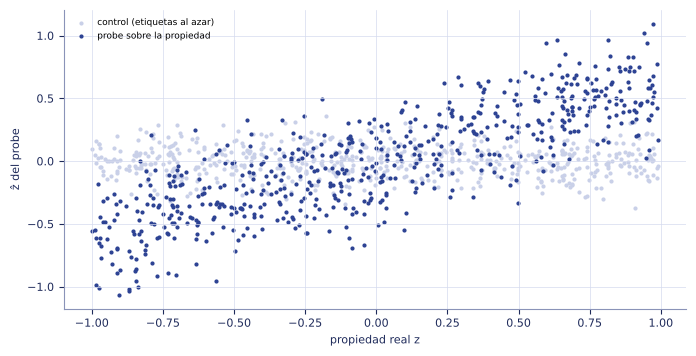

In [31]:
r=np.random.default_rng(10); n,dd=600,256; z=r.uniform(-1,1,n); u=r.normal(0,1,dd); u/=np.linalg.norm(u); H=r.normal(0,1,(n,dd))+3*np.outer(z,u)
pz=cross_val_predict(RidgeCV(alphas=np.logspace(-2,3,20)),H,z,cv=5); pc=cross_val_predict(RidgeCV(alphas=np.logspace(-2,3,20)),H,r.permutation(z),cv=5)
f,a=fig(); a.scatter(z,pc,s=4,c="#C9D0E8",label="control (etiquetas al azar)"); a.scatter(z,pz,s=4,c=NAVY,label="probe sobre la propiedad"); a.set_xlabel("propiedad real z"); a.set_ylabel("ẑ del probe"); a.legend(loc="upper left",fontsize=6.5); save(f,"f13.png")

## 14 · In-context learning de regresión
*Transformers que aprenden regresión lineal dentro del prompt*

- **Configuración:** el prompt contiene pares (x₁, y₁), …, (x_k, y_k) y una consulta x_q.
- **Hallazgo:** transformers entrenados en esta tarea predicen y_q casi como OLS, sin actualizar pesos.
- **Atención lineal = un paso de GD:** con claves xᵢ, valores yᵢ y consulta x_q se obtiene η Σ yᵢ xᵢᵀx_q.
- **Más capas:** equivalen a más pasos de descenso de gradiente (o métodos de segundo orden).
- **Mecanismo:** el modelo implementa un algoritmo de aprendizaje en su pasada hacia adelante.
- **Robustez:** maneja ruido, dispersión (tipo Lasso) y mezclas de regresiones.
- **Límite:** la eficacia cae fuera de la distribución de entrenamiento.
- **Importancia:** la regresión lineal es el banco de pruebas teórico del in-context learning.

**Fórmulas clave:** `ŷ_q = η Σᵢ yᵢ (xᵢ · x_q)` · `w₁ = w₀ − η∇L(w₀) = η Xᵀy`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Ejemplos del contexto de la misma tarea | Verificar la regla generadora; ruido controlado | Filtrar ejemplos |
| Dentro de la distribución de entrenamiento | Probar escalas de x y d distintas | Reportar caída fuera de distribución |
| Suficientes ejemplos (k ≥ d) | Curva de error vs. k frente a OLS | Aumentar k |
| Insensibilidad al orden | Prueba de permutación del orden de ejemplos | Promediar sobre órdenes |
| Formato numérico consistente | Revisar tokenización de los números | Fijar decimales y separadores |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | ¿La atención lineal hace descenso de gradiente? |
| **Datos** | d = 5, 40 pares (xᵢ, yᵢ) en el contexto y una consulta. |
| **Modelo** | Atención lineal vs. un paso de GD desde w = 0. |
| **Resultado** | Ambos predicen 1.3115; OLS = valor real = 1.3626. |
| **Interpretación** | Más capas = más pasos: el error baja hacia OLS. |

**Usos:** *Teoría*: Explicar cómo aprende un modelo dentro del prompt · *Meta-aprendizaje*: Modelos que aprenden a aprender · *Tabulares*: Predictores tipo TabPFN entrenados en tareas sintéticas · *Diseño*: Elegir cuántos ejemplos poner en few-shot · *Robustez*: Estudiar ataques que manipulan el contexto · *Docencia*: Puente entre descenso de gradiente y atención

### Ejemplo en Python — Atención lineal ≡ un paso de GD

In [32]:
import numpy as np

rng = np.random.default_rng(11)
d, k = 5, 40                    # dimensión y nº de ejemplos en el prompt
w_true = rng.normal(0, 1, d)
X = rng.normal(0, 1, (k, d)); y = X @ w_true     # contexto: pares (xᵢ, yᵢ)
xq = rng.normal(0, 1, d)                         # consulta

eta = 1 / k
# Atención lineal: query = xq, keys = xᵢ, values = yᵢ (sin softmax)
y_attn = eta * np.sum(y * (X @ xq))
# Un paso de GD desde w = 0 sobre la pérdida ½Σ(yᵢ − w·xᵢ)²
w_gd = eta * X.T @ y
print("Atención lineal  :", round(y_attn, 4))
print("1 paso de GD     :", round(w_gd @ xq, 4))
print("OLS en contexto  :", round(np.linalg.lstsq(X, y, rcond=None)[0] @ xq, 4))
print("Valor verdadero  :", round(w_true @ xq, 4))

Atención lineal  : 1.3115
1 paso de GD     : 1.3115
OLS en contexto  : 1.3626
Valor verdadero  : 1.3626


**Qué observar**

- Ambas predicciones son idénticas.
- Un paso no alcanza la solución de OLS.
- Apilar capas = más pasos de optimización.

### Visualización

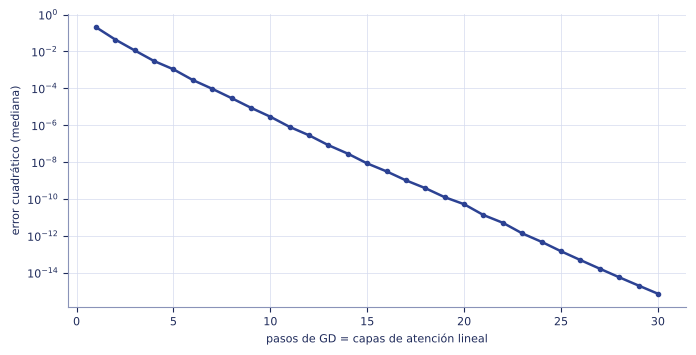

In [33]:
r=np.random.default_rng(11); dd,k=5,40; err=[]
for rep in range(200):
    w=r.normal(0,1,dd); X=r.normal(0,1,(k,dd)); y=X@w; xq=r.normal(0,1,dd); wk=np.zeros(dd); e=[]
    for s_ in range(30): wk=wk+(1/k)*X.T@(y-X@wk); e.append((wk@xq-w@xq)**2)
    err.append(e)
f,a=fig(); a.plot(range(1,31),np.median(err,0),"o-",c=NAVY,ms=3,lw=1.8); a.set_yscale("log"); a.set_xlabel("pasos de GD = capas de atención lineal"); a.set_ylabel("error cuadrático (mediana)"); save(f,"f14.png")

## 15 · LLM como regresores
*Regresión texto a texto y LLM como asistente de análisis*

- **Regresión texto a texto:** x se serializa como texto y el modelo genera y como cadena de dígitos.
- **OmniPred:** un modelo T5 entrenado en datos de muchos experimentos predice métricas numéricas.
- **Few-shot:** incluir ejemplos (x → y) en el prompt de un LLM general.
- **Parseo:** convertir la salida a número de forma robusta (comas, unidades, texto extra).
- **Ventajas:** acepta entradas heterogéneas (texto, tablas, configuraciones) sin ingeniería de características.
- **Riesgos:** alucinación numérica, sensibilidad al formato y costo por predicción.
- **Línea base obligatoria:** comparar siempre con OLS o Ridge con las mismas particiones.
- **Asistente de análisis:** el LLM genera código, interpreta resultados y redacta, pero no reemplaza la verificación.

**Fórmulas clave:** `ŷ = parse( LLM( prompt(x) ) )` · `Comparar MAE_LLM vs. MAE_OLS`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Sin contaminación de datos | Datos privados o posteriores al corte; prueba de memorización | Usar datos nuevos |
| Salida parseable | Tasa de fallos de parseo; JSON con esquema | Formato estricto, reintentos |
| Estabilidad | Varianza entre repeticiones y plantillas; temperatura 0 | Promediar varias respuestas |
| Mejor que la línea base | Prueba pareada de Wilcoxon sobre |errores| vs. OLS | Preferir OLS si no mejora |
| Incertidumbre calibrada | Cobertura de intervalos conformes | Calibrar con residuos |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | Usar texto para predecir precios de vivienda. |
| **Datos** | 12 viviendas: área, habitaciones, precio (millones COP). |
| **Modelo** | Serializar filas como texto + parser numérico; línea base OLS. |
| **Resultado** | Parser: “224,0 millones” → 224.0; OLS = 227.1; real = 220.6. |
| **Interpretación** | Toda predicción en texto se compara contra OLS. |

**Usos:** *AutoML*: Predecir el desempeño de una configuración · *Sistemas*: Estimar latencia o consumo de un programa · *Química*: Propiedades de moléculas desde su descripción · *Negocios*: Estimaciones rápidas desde texto libre · *Educación*: Puntaje a partir de la retroalimentación escrita · *Analítica*: Copiloto que genera e interpreta regresiones

### Ejemplo en Python — Serializar, parsear y comparar

In [34]:
import re, numpy as np
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(12)
area = rng.integers(40, 160, 12); habit = rng.integers(1, 5, 12)
precio = 20 + 1.8 * area + 15 * habit + rng.normal(0, 8, 12)   # millones COP

def serializar(a, h): return f"área={a} m², habitaciones={h}"
prompt = "Predice el precio (millones COP). Responde solo el número.\n"
ejemplos = zip(area[:10], habit[:10], precio[:10])
prompt += "\n".join(f"{serializar(a, h)} -> {p:.0f}" for a, h, p in ejemplos)
prompt += f"\n{serializar(area[10], habit[10])} ->"
print(prompt.splitlines()[-1])

def parsear(texto):                             # salida del LLM → número
    m = re.search(r"-?\d+(?:[.,]\d+)?", texto)
    return float(m.group().replace(",", ".")) if m else np.nan

respuesta = "Estimación: 224,0 millones"   # texto de prueba del parser
print("Número extraído:", parsear(respuesta))
base = LinearRegression().fit(np.c_[area[:10], habit[:10]], precio[:10])
pred = base.predict([[area[10], habit[10]]])[0]
print("Línea base OLS :", round(pred, 1), "| real:", round(precio[10], 1))

área=97 m², habitaciones=2 ->
Número extraído: 224.0
Línea base OLS : 227.1 | real: 220.6


**Qué observar**

- El prompt convierte filas en texto.
- El parser tolera comas y texto extra.
- OLS es la línea base para comparar.

### Visualización

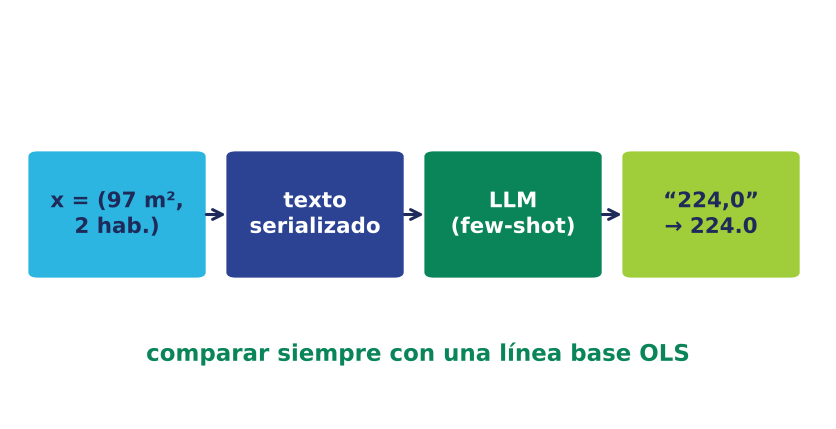

In [35]:
f,a=plt.subplots(figsize=(3.84,1.99),dpi=220); a.axis("off")
bx=[(0.02,"x = (97 m²,\n2 hab.)",CYAN),(0.27,"texto\nserializado",NAVY),(0.52,"LLM\n(few-shot)",GREEN),(0.77,"“224,0”\n→ 224.0",LIME)]
for x0,tx,c in bx:
    a.add_patch(matplotlib.patches.FancyBboxPatch((x0,.35),.2,.3,boxstyle="round,pad=0.01",fc=c,ec=c,transform=a.transAxes))
    a.text(x0+.1,.5,tx,ha="center",va="center",color="white" if c in (NAVY,GREEN) else INK,fontsize=7,weight="bold",transform=a.transAxes)
for x0 in (.225,.475,.725): a.annotate("",xy=(x0+.04,.5),xytext=(x0,.5),xycoords="axes fraction",arrowprops=dict(arrowstyle="->",color=INK))
a.text(.5,.12,"comparar siempre con una línea base OLS",ha="center",color=GREEN,fontsize=7.5,weight="bold",transform=a.transAxes); save(f,"f15.png")

## 16 · Leyes de escala
*Regresión log-lineal para predecir el desempeño de los LLM*

- **Ley de potencia:** la pérdida baja como L(N) = E + A·N^(−α) al crecer los parámetros N.
- **Linealización:** log(L − E) = log A − α·log N es una recta en escala log-log.
- **Estimación:** α y A se obtienen con regresión lineal sobre modelos pequeños.
- **Kaplan et al. (2020):** la pérdida escala de forma predecible con N, datos D y cómputo C.
- **Chinchilla (2022):** con cómputo fijo, N y D deben crecer en proporción (~20 tokens por parámetro).
- **Uso:** extrapolar para decidir el tamaño del modelo antes de gastar el cómputo.
- **Riesgo:** extrapolar fuera del rango; aparecen quiebres y capacidades emergentes discutidas.
- **Lección:** una regresión lineal guía decisiones de millones de dólares en IA.

**Fórmulas clave:** `L(N) = E + A · N^(−α)` · `log(L − E) = log A − α log N`

### Supuestos y validación

| Supuesto | Cómo validarlo | Si no se cumple |
|---|---|---|
| Ley de potencia con E constante | Residuos en log-log sin curvatura; AIC con y sin E | Formas alternativas (quiebres) |
| Mismo protocolo en todos los tamaños | Hiperparámetros óptimos por tamaño registrados | Re-entrenar con barrido justo |
| Validez de la extrapolación | Validación hacia adelante: ajustar en pequeños, predecir el mayor | Acortar el horizonte |
| Errores homocedásticos en log | Residuos vs. log N | Ajuste ponderado o Huber |
| Incertidumbre del exponente | Bootstrap de α (IC 95 %) | Más puntos de tamaño |

### Ejemplo resuelto

| | |
|---|---|
| **Problema** | ¿Qué pérdida tendrá un modelo de 100B parámetros? |
| **Datos** | 12 modelos de 10M a 10B (sintéticos). |
| **Modelo** | Regresión lineal de log(L − E) sobre log N. |
| **Resultado** | α = 0.34, A = 409; pérdida predicha con 100B = 1.76. |
| **Interpretación** | Útil para planear, pero extrapolar exige cautela. |

**Usos:** *Modelos*: Planear el tamaño del próximo modelo · *Datos*: Calcular cuántos tokens recolectar · *Cómputo*: Presupuestar GPU antes de entrenar · *Visión*: Escalado de ViT y CLIP · *Investigación*: Comparar arquitecturas por la pendiente α · *Política*: Pronosticar capacidades futuras

### Ejemplo en Python — Ajustar una ley de escala

In [36]:
import numpy as np
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(13)
N = np.logspace(7, 10, 12)                       # parámetros: 10M → 10B
E_, A, alpha = 1.69, 406.4, 0.34                 # constantes estilo Chinchilla
L = E_ + A * N ** (-alpha) * np.exp(rng.normal(0, 0.02, N.size))   # pérdida

# log(L − E) = log A − α·log N  → regresión lineal en escala log-log
X, y = np.log(N)[:, None], np.log(L - E_)
m = LinearRegression().fit(X, y)
print("α estimado :", round(-m.coef_[0], 3), "(verdadero 0.34)")
print("A estimado :", round(np.exp(m.intercept_), 1))
N_new = 1e11
L_new = E_ + np.exp(m.predict([[np.log(N_new)]])[0])
print("Pérdida predicha con 100B:", round(L_new, 3))

α estimado : 0.34 (verdadero 0.34)
A estimado : 409.1
Pérdida predicha con 100B: 1.764


**Qué observar**

- En log-log la ley de potencia es una recta.
- La pendiente estimada es −α.
- Extrapolar exige cautela.

### Visualización

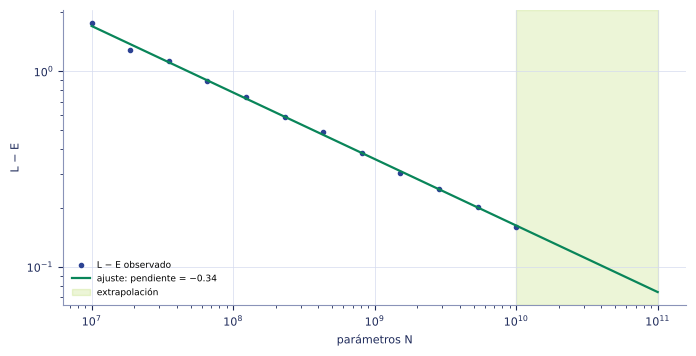

In [37]:
r=np.random.default_rng(13); N=np.logspace(7,10,12); L=1.69+406.4*N**-.34*np.exp(r.normal(0,.02,12)); Nn=np.logspace(7,11,50)
m=LinearRegression().fit(np.log(N)[:,None],np.log(L-1.69))
f,a=fig(); a.loglog(N,L-1.69,"o",c=NAVY,ms=3,label="L − E observado"); a.loglog(Nn,np.exp(m.predict(np.log(Nn)[:,None])),c=GREEN,lw=1.6,label=f"ajuste: pendiente = −{-m.coef_[0]:.2f}")
a.axvspan(1e10,1e11,color=LIME,alpha=.2,label="extrapolación"); a.set_xlabel("parámetros N"); a.set_ylabel("L − E"); a.legend(fontsize=6.5); save(f,"f16.png")

---
## Ejercicios
1. Cambia las semillas de los tópicos 07, 10 y 13: ¿qué resultados son estables y cuáles no?
2. Tópico 10: repite la predicción conforme con α = 0.05 y verifica la cobertura.
3. Tópico 14: varía `k` (número de ejemplos en contexto) y grafica el error del paso de GD frente a OLS.
4. Tópico 15: con una API real, compara el MAE del LLM y de OLS en 30 viviendas nuevas.
5. Tópico 16: ajusta la ley de escala usando solo los 6 modelos más pequeños y mide el error de extrapolación.